# HYPE Curve Analysis

Análisis del patrón de las curvas de momentum (HYPE) calculadas por el finviz dashboard.

**Preguntas a responder:**
1. ¿El patrón se repite entre días/tickers?
2. ¿Hay un punto óptimo de entrada basado en la curva?
3. ¿Depende del tipo de activo (precio, volatilidad)?
4. ¿Qué señal (`confirmed`, `accelerating`, `trending`, etc.) predice mejor el movimiento posterior?

**Datos:**
- `snapshots`: raw finviz data, 24-mar a 15-abr, ~15-20 tickers/día
- `hype_metrics`: métricas momentum calculadas (densa desde 14-abr)
- `market_bars`: barras 1-min intraday, densa desde 10-abr

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

DB_PATH = '/Users/carlos/Library/Application Support/finviz-dashboard/finviz_snapshots.db'
conn = sqlite3.connect(DB_PATH)
print('DB connected')

DB connected


### Que estamos cargando

- **snapshots**: cada vez que el dashboard hace polling a Finviz, guarda el % de cambio y el precio de cada ticker en Top Gainers. Es la materia prima de las curvas HYPE.
- **hype_metrics**: las metricas calculadas por el engine (mom_score, velocity, señal) a partir de los snapshots. `source='finviz'` viene de snapshots; `source='ibkr'` viene de barras de 1 minuto de IBKR.
- **market_bars**: barras de precio de 1 minuto por ticker. Las usamos para saber que hizo el precio DESPUES de que apareció la señal HYPE.

## 1. Carga de datos

In [2]:
# --- Snapshots (raw finviz) ---
snaps = pd.read_sql("""
    SELECT ticker, timestamp, price, change_pct, volume, category
    FROM snapshots
    WHERE category = 'Top Gainers'
    ORDER BY ticker, timestamp
""", conn)

snaps['ts'] = pd.to_datetime(snaps['timestamp'], utc=True).dt.tz_convert('America/New_York')
snaps['day'] = snaps['ts'].dt.date.astype(str)
snaps['price_f'] = pd.to_numeric(snaps['price'].str.replace('$','').str.replace(',',''), errors='coerce')
snaps['chg_f'] = pd.to_numeric(snaps['change_pct'].str.replace('%','').str.strip(), errors='coerce')

def parse_vol(v):
    if not v: return 0
    s = str(v).upper().replace(',','')
    try:
        if s.endswith('B'): return float(s[:-1]) * 1e9
        if s.endswith('M'): return float(s[:-1]) * 1e6
        if s.endswith('K'): return float(s[:-1]) * 1e3
        return float(s)
    except: return 0

snaps['vol_f'] = snaps['volume'].apply(parse_vol)
snaps = snaps[snaps['chg_f'] > 0].reset_index(drop=True)

print(f"Snapshots: {len(snaps)} rows, {snaps['ticker'].nunique()} tickers, {snaps['day'].nunique()} days")
print(snaps['day'].value_counts().sort_index())

Snapshots: 3182 rows, 150 tickers, 15 days
day
2026-03-24    150
2026-03-25    144
2026-03-26    144
2026-03-27    150
2026-03-30    150
2026-04-01     54
2026-04-02    150
2026-04-06    175
2026-04-07    175
2026-04-08    150
2026-04-09    144
2026-04-10    306
2026-04-13    438
2026-04-14    408
2026-04-15    444
Name: count, dtype: int64


In [3]:
# --- Hype metrics (computed by engine) ---
hype = pd.read_sql("""
    SELECT ticker, timestamp, signal, 
           rel_volume as persistence,
           hype_cum as mom_score,
           delta_5m as velocity,
           delta_15m as chg_initial,
           delta_1h as chg_now,
           close_price
    FROM hype_metrics
    ORDER BY ticker, timestamp
""", conn)

import pytz, dateutil.parser
ET_tz = pytz.timezone("America/New_York")

def parse_ts_mixed(ts_str):
    dt = dateutil.parser.parse(ts_str)
    if dt.tzinfo is None:
        return ET_tz.localize(dt)
    return dt.astimezone(ET_tz)

hype["ts"] = hype["timestamp"].apply(parse_ts_mixed)
hype["day"] = hype["ts"].apply(lambda x: x.strftime("%Y-%m-%d"))

days = sorted(hype["day"].unique())
print(f"Hype metrics: {len(hype)} rows")
print(f"Days: {days}")
print("Signal distribution:")
print(hype["signal"].value_counts())

Hype metrics: 31697 rows
Days: ['2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-04-01', '2026-04-02', '2026-04-07', '2026-04-08', '2026-04-09', '2026-04-10', '2026-04-14', '2026-04-15']
Signal distribution:
signal
trending          6882
early_momentum    3983
topping           2123
spike             1608
confirmed         1245
new               1075
accelerating       579
Name: count, dtype: int64


In [4]:
# --- Market bars (1-min intraday) ---
MB = pd.read_sql("""
    SELECT ticker, bar_time, open, high, low, close, volume
    FROM market_bars
    ORDER BY ticker, bar_time
""", conn)

MB['ts'] = pd.to_datetime(MB['bar_time'])
# bar_time stored without timezone — assume ET
MB['ts'] = MB['ts'].dt.tz_localize('America/New_York', ambiguous='NaT', nonexistent='NaT')
MB['day'] = MB['ts'].dt.strftime('%Y-%m-%d')

print(f"Market bars: {len(MB)} rows, {MB['ticker'].nunique()} tickers")
print(f"Days with bars: {sorted(MB['day'].unique())[-15:]}")

# --- Burst intraday cache (backfill adicional) ---
import pathlib as _pl
DB_BURST = str(_pl.Path('/Users/carlos/proyectos/TRADING/1_PROYECTOS_ACTIVOS/CLAUDE/finviz-dashboard/analysis/burst_intraday_cache.db'))
try:
    import sqlite3 as _sq
    with _sq.connect(DB_BURST) as _cb:
        mb_burst = pd.read_sql(
            "SELECT symbol AS ticker, date||'T'||dt AS bar_time, open, high, low, close, volume FROM bars",
            _cb
        )
    mb_burst['ts']  = pd.to_datetime(mb_burst['bar_time']).dt.tz_localize('America/New_York', ambiguous='NaT', nonexistent='NaT')
    mb_burst['day'] = mb_burst['ts'].dt.strftime('%Y-%m-%d')
    MB = pd.concat([MB, mb_burst], ignore_index=True).drop_duplicates(subset=['ticker', 'ts'])
    print(f"MB combinado (market_bars + burst_cache): {len(MB)} barras, {MB['ticker'].nunique()} tickers, {MB['day'].nunique()} dias")
    print(f"Dias disponibles: {sorted(MB['day'].unique())}")
except Exception as _e:
    print(f"[WARN] burst_intraday_cache no cargado: {_e}")


Market bars: 154443 rows, 120 tickers
Days with bars: ['2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09', '2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15']


### Como funciona la curva HYPE

El dashboard no dibuja el precio del ticker. Dibuja el **momentum score** (`mom_score`):

```
mom_score = chg_initial × signo(velocity) × log(1 + persistence)
```

- **chg_initial**: el % de subida del ticker cuando apareció por primera vez en Top Gainers (ej: +28%).
- **velocity**: si el % de cambio está subiendo o bajando con el tiempo. Positivo = el ticker sigue acelerando. Negativo = está perdiendo momentum.
- **persistence**: cuántas veces ha aparecido en Top Gainers ese día. Más apariciones = más tiempo aguantando el movimiento.

**Resultado**: la curva sube cuando el ticker mantiene o acelera su movimiento, y baja (o se vuelve negativa) cuando empieza a perder fuerza, aunque el precio todavía no haya caído visiblemente.

## 2. Reconstrucción de curvas HYPE desde snapshots

Para cada ticker×día calculamos la evolución temporal de `chg_pct` (curva HYPE) y métricas derivadas.

In [5]:
import math

MARKET_OPEN_MIN = 9 * 60 + 30  # 9:30 ET

def time_to_min(ts):
    return ts.hour * 60 + ts.minute - MARKET_OPEN_MIN

def compute_trajectory(df_ticker):
    df = df_ticker.sort_values('ts').copy()
    df = df[df['chg_f'].notna() & (df['chg_f'] > 0)].reset_index(drop=True)
    if len(df) < 2:
        return None

    t0 = df['ts'].iloc[0]
    df['elapsed_min'] = (df['ts'] - t0).dt.total_seconds() / 60
    df['time_min']    = df['ts'].apply(time_to_min)

    chg_initial = float(df['chg_f'].iloc[0])
    chg_vals    = df['chg_f'].values
    elapsed     = df['elapsed_min'].values

    mom_scores = []
    velocities = []
    for i in range(len(df)):
        sub_elapsed = elapsed[:i+1]
        sub_chg     = chg_vals[:i+1]
        if i < 1:
            vel = 0.0
        else:
            try:
                vel = float(np.polyfit(sub_elapsed, sub_chg, 1)[0])
            except Exception:
                vel = 0.0
        persistence_i = i + 1
        chg_init_i    = float(sub_chg[0])
        score = chg_init_i * math.copysign(1, vel) * math.log1p(persistence_i) if vel != 0 else 0.0
        mom_scores.append(score)
        velocities.append(vel)

    df['mom_score'] = mom_scores
    df['velocity']  = velocities

    final_vel = velocities[-1]
    return {
        'df':             df,
        'chg_initial':    chg_initial,
        'chg_peak':       float(df['chg_f'].max()),
        'chg_final':      float(df['chg_f'].iloc[-1]),
        'price_initial':  float(df['price_f'].iloc[0]) if pd.notna(df['price_f'].iloc[0]) else 0,
        'price_final':    float(df['price_f'].iloc[-1]) if pd.notna(df['price_f'].iloc[-1]) else 0,
        'velocity':       final_vel,
        'persistence':    len(df),
        'duration_min':   float(df['elapsed_min'].iloc[-1]),
        'first_seen':     t0,
        'last_seen':      df['ts'].iloc[-1],
        'peak_mom_score': max(mom_scores) if mom_scores else 0,
        'final_mom_score':mom_scores[-1]  if mom_scores else 0,
    }

trajectories = {}
for (ticker, day), grp in snaps.groupby(['ticker', 'day']):
    traj = compute_trajectory(grp)
    if traj:
        trajectories[(ticker, day)] = traj

print(f"Trajectories computed: {len(trajectories)} ticker-day pairs")


Trajectories computed: 168 ticker-day pairs


In [6]:
# Resumen de trayectorias
traj_summary = []
for (ticker, day), t in trajectories.items():
    traj_summary.append({
        'ticker': ticker,
        'day': day,
        'chg_initial': t['chg_initial'],
        'chg_peak': t['chg_peak'],
        'chg_final': t['chg_final'],
        'price_initial': t['price_initial'],
        'price_final': t['price_final'],
        'velocity': t['velocity'],
        'persistence': t['persistence'],
        'duration_min': t['duration_min'],
        'first_seen': t['first_seen'],
    })

tdf = pd.DataFrame(traj_summary)
tdf['chg_decay'] = tdf['chg_final'] - tdf['chg_initial']
tdf['momentum_type'] = pd.cut(tdf['chg_initial'], bins=[0,15,20,40,100], labels=['<15%','15-20%','20-40%','>40%'])

cols = ['chg_initial','chg_peak','chg_final','persistence','velocity']
print(tdf.groupby('day')[cols].agg(['mean','count']).round(2))
tdf.head(10)

           chg_initial       chg_peak       chg_final       persistence        \
                  mean count     mean count      mean count        mean count   
day                                                                             
2026-03-24       40.89    10    64.26    10     57.16    10       14.70    10   
2026-03-25       41.27    14    71.04    14     59.56    14        9.93    14   
2026-03-26       79.41     8   113.40     8     80.85     8       18.00     8   
2026-03-27       72.63    11   124.67    11     77.01    11       13.00    11   
2026-03-30       68.02    10    95.43    10     73.99    10       14.80    10   
2026-04-01      102.84     8   111.47     8    105.44     8        6.75     8   
2026-04-02       52.80    12    66.78    12     54.85    12       12.50    12   
2026-04-06       64.58    10   117.32    10     93.76    10       17.30    10   
2026-04-07       64.42    15    94.59    15     71.37    15       11.53    15   
2026-04-08       73.89    11

,ticker,day,chg_initial,chg_peak,chg_final,price_initial,price_final,velocity,persistence,duration_min,first_seen,chg_decay,momentum_type
0,ADVB,2026-04-07,69.54,69.54,49.66,7.49,6.61,-0.168209,7,90.933333,2026-04-07 09:46:08-04:00,-19.88,>40%
1,AFJK,2026-04-09,51.25,181.68,135.71,42.35,66.00,0.269347,19,272.283333,2026-04-09 11:15:58-04:00,84.46,>40%
2,AFJK,2026-04-14,35.69,73.46,44.18,54.82,58.25,0.013989,31,188.983333,2026-04-14 10:31:36-04:00,8.49,20-40%
3,AGAE,2026-04-15,86.71,169.24,63.38,0.61,0.54,0.191575,74,369.450000,2026-04-15 09:49:11-04:00,-23.33,>40%
4,AGPU,2026-04-01,111.73,116.04,113.89,3.43,3.46,0.001239,9,120.866667,2026-04-01 13:55:41-04:00,2.16,NaN
5,AGX,2026-03-27,32.50,40.42,38.87,544.37,570.54,0.021217,18,336.616667,2026-03-27 10:00:12-04:00,6.37,20-40%
6,AIB,2026-04-06,39.64,49.14,42.67,1.62,1.65,0.017226,18,257.583333,2026-04-06 09:46:45-04:00,3.03,20-40%
7,AIFF,2026-03-26,55.36,76.19,76.19,2.61,2.96,0.072744,9,198.600000,2026-03-26 12:28:35-04:00,20.83,>40%
8,AIXI,2026-04-02,55.24,55.24,40.83,0.15,0.14,-0.474833,3,30.350000,2026-04-02 12:38:04-04:00,-14.41,>40%
9,AIXI,2026-04-06,102.07,397.34,397.34,0.26,0.65,0.577543,25,363.466667,2026-04-06 09:46:45-04:00,295.27,NaN


## 3. Visualización de curvas HYPE por día

¿Qué formas toman las curvas? ¿Se distinguen patrones?

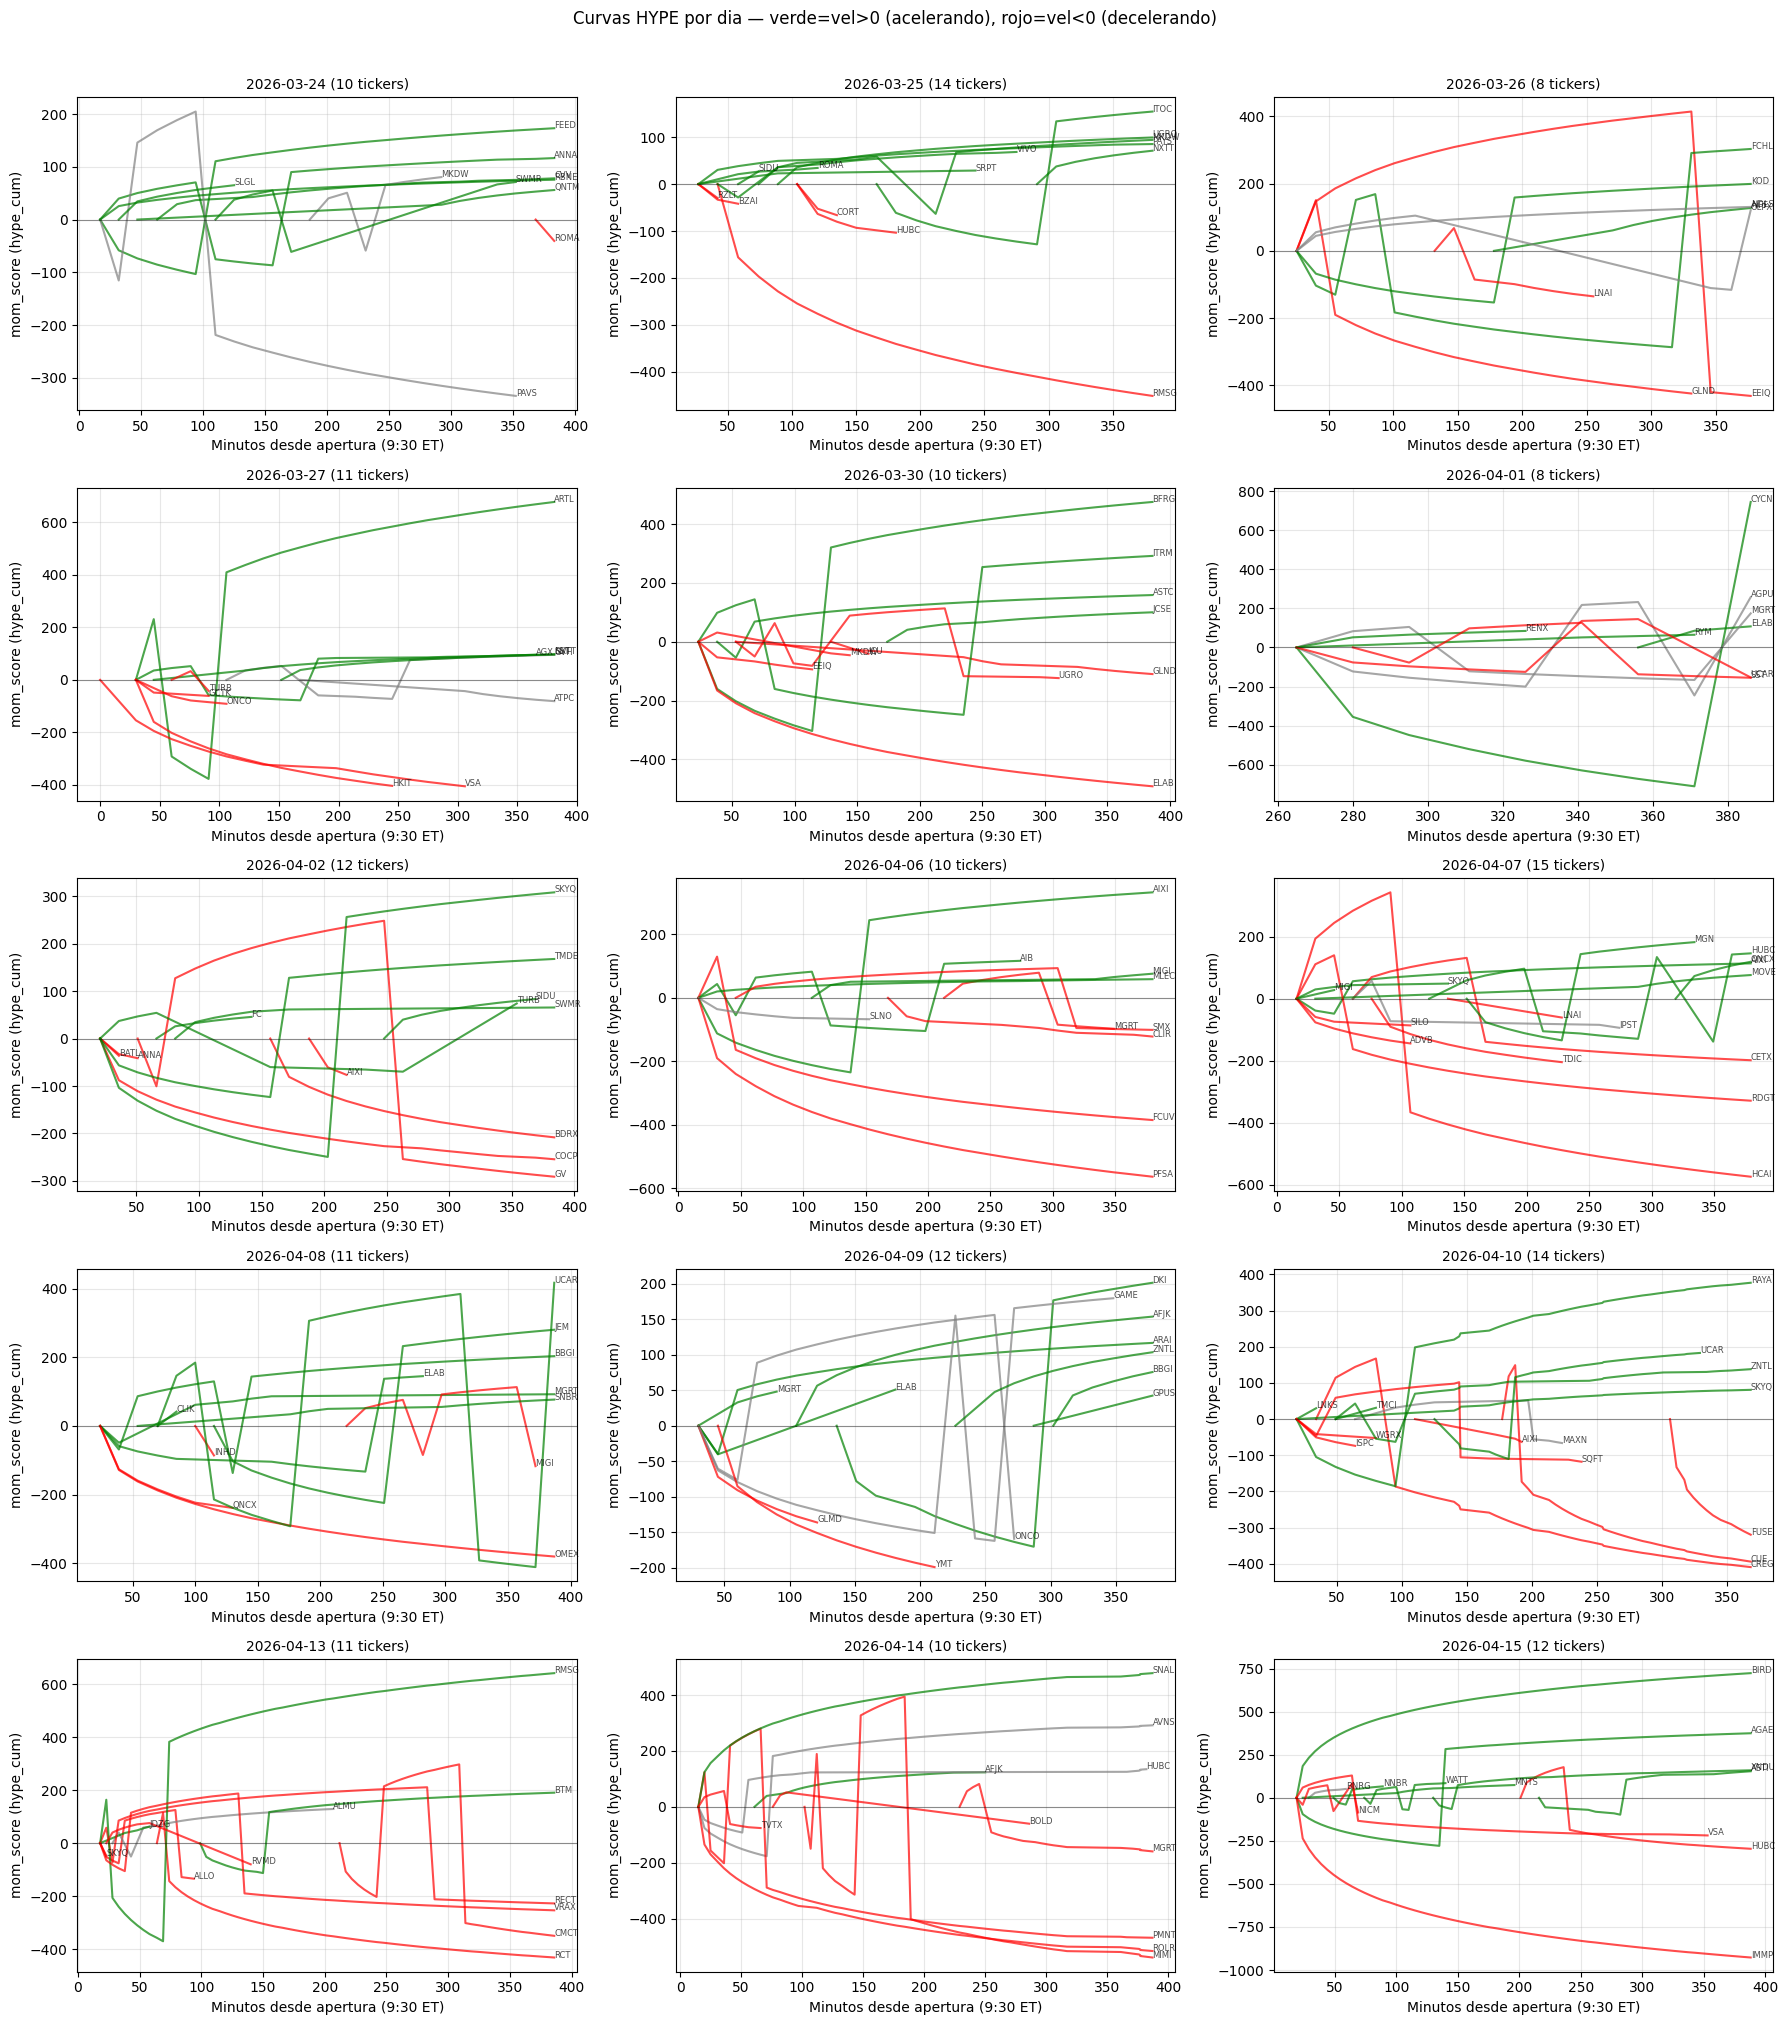

Guardado: hype_curves_by_day.png


In [7]:
# Curvas HYPE (mom_score vs time_min) - igual que el Finviz Dashboard
days = sorted(snaps['day'].unique())
n_days = len(days)
cols = 3
rows = (n_days + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, day in enumerate(days):
    ax = axes[i]
    day_tickers = [(t, d) for (t, d) in trajectories.keys() if d == day]

    for (ticker, d) in day_tickers:
        traj = trajectories[(ticker, d)]
        df = traj['df']
        vel = traj['velocity']
        color = 'green' if vel > 0.01 else ('red' if vel < -0.01 else 'gray')
        # Plot mom_score vs time_min — this matches the dashboard HYPE curve
        ax.plot(df['time_min'], df['mom_score'], alpha=0.7, linewidth=1.5, color=color)
        ax.annotate(ticker, xy=(df['time_min'].iloc[-1], df['mom_score'].iloc[-1]),
                    fontsize=6, alpha=0.7)

    ax.axhline(0, color='black', linestyle='-', alpha=0.4, linewidth=0.8)
    ax.set_title(f'{day} ({len(day_tickers)} tickers)', fontsize=10)
    ax.set_xlabel('Minutos desde apertura (9:30 ET)')
    ax.set_ylabel('mom_score (hype_cum)')
    ax.grid(True, alpha=0.3)

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Curvas HYPE por dia — verde=vel>0 (acelerando), rojo=vel<0 (decelerando)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('hype_curves_by_day.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado: hype_curves_by_day.png')

### Clasificacion de formas de curva

Cada curva HYPE tiene una forma característica:

| Forma | Descripcion | Color |
|-------|-------------|-------|
| **rocket** | Sube todo el tiempo — momentum creciente | Verde |
| **plateau** | Se estabiliza — momentum constante | Azul |
| **topping** | Sube y luego baja — momentum que se agota | Naranja |
| **fade** | Baja todo el tiempo — señal que muere | Rojo |
| **mixed** | Sin patron claro | Gris |

## 4. Análisis de patrones de forma de curva

Clasificamos las trayectorias en tipos: rocket, plateau, topping, fade

In [8]:
def classify_curve_shape(traj):
    """
    Clasifica la FORMA VISUAL de la curva HYPE (mom_score) en 4 tipos.

    LIMITACION IMPORTANTE: esta clasificacion es RETROSPECTIVA (usa toda la curva)
    y CIRCULAR para prediccion (mom_score incorpora velocity, que usamos para clasificar).
    Util para descripcion visual; NO usar como señal predictiva directa.
    """
    df     = traj['df']
    scores = df['mom_score'].values
    if len(scores) < 3:
        return 'insufficient'
    mid = len(scores) // 2
    if mid < 1:
        return 'insufficient'

    first_half_slope  = np.polyfit(range(mid+1),           scores[:mid+1], 1)[0]
    second_half_slope = np.polyfit(range(len(scores)-mid), scores[mid:],   1)[0]
    overall_slope     = traj['velocity']
    delta             = scores[-1] - scores[0]

    if overall_slope > 0.05 and delta > 5:      return 'rocket'
    if first_half_slope > 0 and second_half_slope < -0.01: return 'topping'
    if abs(delta) < 5 and abs(overall_slope) < 0.02:       return 'plateau'
    if overall_slope < -0.05 or delta < -10:               return 'fade'
    return 'mixed'

tdf['curve_shape'] = [
    classify_curve_shape(trajectories[(r.ticker, r.day)])
    if (r.ticker, r.day) in trajectories else 'unknown'
    for _, r in tdf.iterrows()
]

print("Distribucion de formas de curva (descripcion visual, no predictiva):")
print(tdf['curve_shape'].value_counts())


Distribucion de formas de curva (descripcion visual, no predictiva):
curve_shape
fade            52
rocket          50
mixed           35
topping         18
insufficient    13
Name: count, dtype: int64


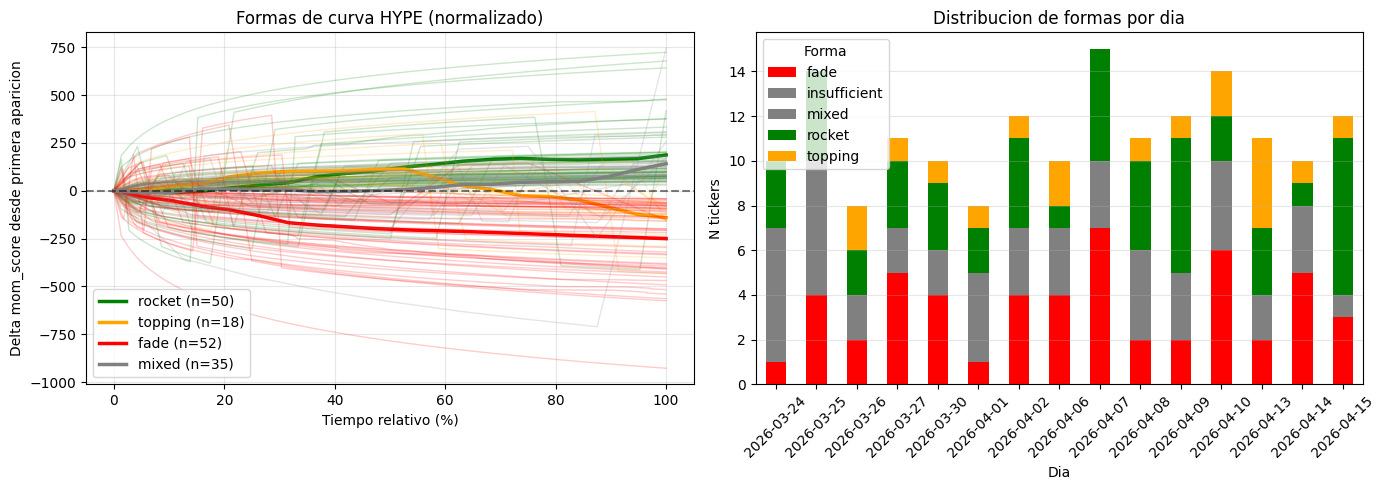

In [9]:
shape_colors = {'rocket': 'green', 'plateau': 'blue', 'topping': 'orange', 'fade': 'red', 'mixed': 'gray'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for shape, color in shape_colors.items():
    curves = []
    for (ticker, day), traj in trajectories.items():
        row = tdf[(tdf.ticker==ticker) & (tdf.day==day)]
        if not row.empty and row.iloc[0]['curve_shape'] == shape:
            df = traj['df']
            if len(df) >= 3 and traj['duration_min'] > 0:
                t_norm = df['elapsed_min'] / traj['duration_min'] * 100
                score_norm = df['mom_score'] - df['mom_score'].iloc[0]  # relative to start
                curves.append((t_norm.values, score_norm.values))

    if curves:
        for t_norm, score_norm in curves:
            ax.plot(t_norm, score_norm, alpha=0.2, color=color, linewidth=1)
        t_interp = np.linspace(0, 100, 20)
        means = [np.mean([np.interp(ti, c[0], c[1]) for c in curves]) for ti in t_interp]
        ax.plot(t_interp, means, color=color, linewidth=2.5, label=f'{shape} (n={len(curves)})')

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Tiempo relativo (%)')
ax.set_ylabel('Delta mom_score desde primera aparicion')
ax.set_title('Formas de curva HYPE (normalizado)')
ax.legend()
ax.grid(True, alpha=0.3)

ax2 = axes[1]
day_shape = tdf.groupby(['day','curve_shape']).size().unstack(fill_value=0)
day_shape.plot(kind='bar', ax=ax2, stacked=True,
               color=[shape_colors.get(c,'gray') for c in day_shape.columns])
ax2.set_title('Distribucion de formas por dia')
ax2.set_xlabel('Dia')
ax2.set_ylabel('N tickers')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Forma')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('hype_curve_shapes.png', dpi=120, bbox_inches='tight')
plt.show()

### Como leer el analisis de edge

Para cada grupo de señales calculamos estas métricas:

| Metrica | Que mide | Referencia para tener edge |
|---------|----------|----------------------------|
| **Profit Factor (PF)** | Dinero ganado / dinero perdido en total | > 1.0 (break-even), > 1.5 (bueno) |
| **EV (Expected Value)** | Retorno medio esperado por trade | > 0% |
| **Win Rate (WR)** | % de trades que acaban en positivo | > 50% (aunque con buen R/R puede ser menor) |
| **R/R ratio** | Ganancia media / perdida media | > 1.0 (ganas mas de lo que pierdes) |
| **Kelly %** | Fraccion optima de capital a arriesgar | > 0% (negativo = no hay edge) |
| **p-value Bonferroni** | Probabilidad de que el resultado sea por azar | < 0.05 (significativo) |

**SESGO IMPORTANTE**: Solo tenemos datos de los dias en que el sistema tenia market_bars activos (tickers que ya estaba monitorizando). No es una muestra aleatoria de todos los Top Gainers. Con mas dias de datos las conclusiones seran mas robustas.

## 5. Edge real: prediccion del movimiento de precio

Analisis en dos capas:
- **Capa A**: senales finviz (`confirmed/topping/accelerating`) vs retorno de precio en dias con market_bars
- **Capa B**: senales ibkr por minuto (14-abr) — `trending/spike/early_momentum` vs retorno siguiente

In [10]:
# === CAPA A: senales finviz vs precio ===
# CORRECCIONES APLICADAS:
#   1. Entrada al open de la barra POSTERIOR (>) al snapshot
#   2. Senal solo la del momento de entrada (sin look-ahead)
#   3. UNA sola observacion por ticker-dia (evita correlacion artificial)
#   4. Normalizar vel_early por tiempo real entre snapshots

import sqlite3, math, pytz, dateutil.parser
import pandas as pd
import numpy as np

DB_PATH_C = '/Users/carlos/Library/Application Support/finviz-dashboard/finviz_snapshots.db'
conn2  = sqlite3.connect(DB_PATH_C)
ET_tz2 = pytz.timezone('America/New_York')

def parse_ts2(ts_str):
    dt = dateutil.parser.parse(ts_str)
    return dt.astimezone(ET_tz2) if dt.tzinfo else ET_tz2.localize(dt)

def fwd_return(ticker, entry_ts, day_bars_df, minutes):
    # Barra estrictamente posterior (>) al snapshot — evita usar barra en curso
    future = day_bars_df[
        (day_bars_df.ticker == ticker) & (day_bars_df.ts > entry_ts)
    ].sort_values('ts')
    if future.empty: return None, None, None
    ep = float(future.iloc[0]['open'])
    if ep <= 0: return None, None, None
    cutoff = entry_ts + pd.Timedelta(minutes=minutes)
    window = future[future.ts <= cutoff]
    if window.empty: return None, None, None
    ret = (float(window.iloc[-1]['close']) - ep) / ep * 100
    mfe = (float(window['high'].max()) - ep) / ep * 100
    mae = (ep - float(window['low'].min())) / ep * 100
    return ret, mfe, mae

hf = pd.read_sql("SELECT * FROM hype_metrics WHERE source='finviz' ORDER BY ticker, timestamp", conn2)
hf['ts']  = hf['timestamp'].apply(parse_ts2)
hf['day'] = hf['ts'].apply(lambda x: x.strftime('%Y-%m-%d'))

mb = MB.copy()  # reutiliza MB ya cargado en cell 6 (evita releer 154k filas)

print(f"[SELECTION BIAS] hype_metrics tickers: {hf.ticker.nunique()}")
print(f"[SELECTION BIAS] market_bars tickers:  {mb.ticker.nunique()}")
print(f"[SELECTION BIAS] market_bars NO es muestra aleatoria — solo tickers monitorizados activamente")
print()

records = []
for (ticker, day), grp in hf.groupby(['ticker', 'day']):
    grp      = grp.sort_values('ts')
    day_bars = mb[mb.day == day]
    if day_bars.empty: continue

    first_row      = grp.iloc[0]
    entry_ts       = first_row['ts']
    signal_at_entry = first_row['signal']

    # Normalizar vel_early por tiempo real entre snapshots (no por indice)
    if len(grp) >= 3:
        t0   = grp.iloc[0]['ts']; t2 = grp.iloc[2]['ts']
        dt   = (t2 - t0).total_seconds() / 60
        vel_early_norm = (float(grp.iloc[2]['delta_15m'] or 0) -
                          float(grp.iloc[0]['delta_15m'] or 0)) / dt if dt > 0 else 0
    else:
        vel_early_norm = 0

    # UNA sola observacion por ticker-dia (solo la primera aparicion)
    for h in [15, 30, 60]:
        ret, mfe, mae = fwd_return(ticker, entry_ts, day_bars, h)
        if ret is None: continue
        records.append({
            'ticker':          ticker,
            'day':             day,
            'signal_at_entry': signal_at_entry,
            'chg_initial':     float(first_row['delta_15m'] or 0),
            'persistence_max': float(grp['rel_volume'].max()),
            'mom_score_peak':  float(grp['hype_cum'].max()),
            'vel_early_norm':  vel_early_norm,
            'horizon':         h,
            'ret':  ret, 'mfe': mfe, 'mae': mae,
            'win':  int(ret > 0),
            'snap_time_min': entry_ts.hour * 60 + entry_ts.minute - 570,
        })

rA = pd.DataFrame(records)
print(f"CAPA A: {len(rA)} registros UNICOS por ticker-dia, {rA.ticker.nunique()} tickers, {rA.day.nunique()} dias")
print(f"(Antes habia multiples obs por ticker — ahora 1 por dia, independientes)")
print()
for h in [15, 30, 60]:
    sub = rA[rA.horizon == h]
    if sub.empty: continue
    agg = sub.groupby('signal_at_entry').agg(
        n=('ret','count'),
        wr_pct=('win', lambda x: round(x.mean()*100,1)),
        ret_mean=('ret', lambda x: round(x.mean(),2)),
        ret_median=('ret', lambda x: round(x.median(),2)),
        mfe_mean=('mfe', lambda x: round(x.mean(),2)),
        mae_mean=('mae', lambda x: round(x.mean(),2)),
    )
    print(f"--- +{h}min (1 obs/ticker-dia, senal en momento de entrada) ---")
    print(agg.to_string())
    print()


[SELECTION BIAS] hype_metrics tickers: 169
[SELECTION BIAS] market_bars tickers:  120
[SELECTION BIAS] market_bars NO es muestra aleatoria — solo tickers monitorizados activamente

CAPA A: 69 registros UNICOS por ticker-dia, 22 tickers, 3 dias
(Antes habia multiples obs por ticker — ahora 1 por dia, independientes)

--- +15min (1 obs/ticker-dia, senal en momento de entrada) ---
                 n  wr_pct  ret_mean  ret_median  mfe_mean  mae_mean
signal_at_entry                                                     
accelerating     1   100.0      1.04        1.04      5.55      1.39
confirmed        3    66.7     -1.33        1.35      4.63      5.56
new              5    60.0      1.13        0.93     10.92      3.98
topping          8    37.5      0.08       -0.04      1.44      0.87

--- +30min (1 obs/ticker-dia, senal en momento de entrada) ---
                 n  wr_pct  ret_mean  ret_median  mfe_mean  mae_mean
signal_at_entry                                                     
acc

In [11]:
# Plot CAPA A
if len(rA) > 0:
    signal_order = [s for s in ['confirmed','accelerating','new','topping']
                    if s in rA['signal_at_entry'].values]
    colors_map = {'confirmed':'green','accelerating':'royalblue','new':'gray','topping':'red'}
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, h in zip(axes, [15, 30, 60]):
        sub = rA[(rA.horizon == h) & rA['signal_at_entry'].isin(signal_order)]
        if sub.empty:
            ax.text(0.5, 0.5, f'Sin datos h={h}m', ha='center', va='center', transform=ax.transAxes)
            continue
        for i, sig in enumerate(signal_order):
            vals = sub[sub.signal_at_entry == sig]['ret'].dropna()
            if vals.empty:
                continue
            c = colors_map.get(sig, 'gray')
            ax.scatter([sig]*len(vals), vals, alpha=0.5, color=c, s=40, zorder=3)
            ax.hlines(vals.mean(), i-0.3, i+0.3, colors=c, linewidth=3, zorder=5)
            wr = (vals > 0).mean() * 100
            ax.text(i, vals.mean()+0.5, f"WR={wr:.0f}%\n{vals.mean():+.1f}%",
                    ha='center', fontsize=8, fontweight='bold')
        ax.axhline(0, color='black', linestyle='--', alpha=0.5)
        ax.set_xticks(range(len(signal_order)))
        ax.set_xticklabels(signal_order, rotation=15)
        ax.set_title(f'+{h}min retorno por senal (en momento de snapshot)')
        ax.set_ylabel('Retorno %')
        ax.grid(True, alpha=0.3, axis='y')
    plt.suptitle('CAPA A — Edge por senal finviz (sin look-ahead)', fontsize=12)
    plt.tight_layout()
    plt.savefig('edge_finviz_signals.png', dpi=120, bbox_inches='tight')
    plt.show()


KeyError: 'signal_at_entry'

In [ ]:
# === CAPA B: senales ibkr por minuto (14-abr) — VERSION SIN SESGOS ===
# Sesgo 1 corregido: barra estrictamente posterior (>) al momento de senal
# Nota: Capa B solo tiene 1 dia — conclusiones solo orientativas

hype_ibkr = pd.read_sql(
    "SELECT ticker, timestamp, signal, hype_cum, delta_5m as velocity, rel_volume as persistence, close_price "
    "FROM hype_metrics WHERE source='ibkr' ORDER BY ticker, timestamp", conn2)
hype_ibkr['ts'] = hype_ibkr['timestamp'].apply(parse_ts2)
hype_ibkr['day'] = hype_ibkr['ts'].apply(lambda x: x.strftime('%Y-%m-%d'))
bars_14 = mb[mb.day == '2026-04-14']

print(f"CAPA B: {len(hype_ibkr)} filas ibkr, {hype_ibkr['ticker'].nunique()} tickers")
print(f"Senales: {hype_ibkr['signal'].value_counts().to_dict()}")
print()

records_b = []
for ticker, grp in hype_ibkr.groupby('ticker'):
    grp = grp.sort_values('ts')
    for _, row in grp[grp['signal'].notna()].iterrows():
        for h in [15, 30]:
            # fwd_return ya usa > (barra posterior) — correcto
            ret, mfe, mae = fwd_return(ticker, row['ts'], bars_14, h)
            if ret is None:
                continue
            records_b.append({
                'ticker': ticker,
                'signal': row['signal'],
                'hype_cum': float(row['hype_cum'] or 0),
                'velocity': float(row['velocity'] or 0),
                'persistence': float(row['persistence'] or 0),
                'horizon': h,
                'ret': ret, 'mfe': mfe, 'mae': mae,
                'win': int(ret > 0),
            })

rB = pd.DataFrame(records_b)
print(f"Capa B registros: {len(rB)}")
print()
for h in [15, 30]:
    sub = rB[rB.horizon == h]
    if sub.empty:
        continue
    agg = sub.groupby('signal').agg(
        n=('ret','count'),
        wr_pct=('win', lambda x: round(x.mean()*100, 1)),
        ret_mean=('ret', lambda x: round(x.mean(), 2)),
        ret_median=('ret', lambda x: round(x.median(), 2)),
        mfe_mean=('mfe', lambda x: round(x.mean(), 2)),
        mae_mean=('mae', lambda x: round(x.mean(), 2)),
    )
    print(f"--- +{h}min | senales ibkr ---")
    print(agg.to_string())
    print()


CAPA B: 24724 filas ibkr, 40 tickers
Senales: {'trending': 6882, 'early_momentum': 3977, 'spike': 1602}

Capa B registros: 24920

--- +15min | senales ibkr ---
                   n  wr_pct  ret_mean  ret_median  mfe_mean  mae_mean
signal                                                                
early_momentum  3976    47.7      0.17         0.0      2.09      1.75
spike           1602    43.1     -0.93        -0.1      2.77      3.33
trending        6882    46.4      0.02         0.0      2.44      2.24

--- +30min | senales ibkr ---
                   n  wr_pct  ret_mean  ret_median  mfe_mean  mae_mean
signal                                                                
early_momentum  3976    48.2      0.40        0.00      3.22      2.46
spike           1602    43.3     -1.15       -0.15      3.63      4.26
trending        6882    45.7     -0.01       -0.04      3.56      3.11



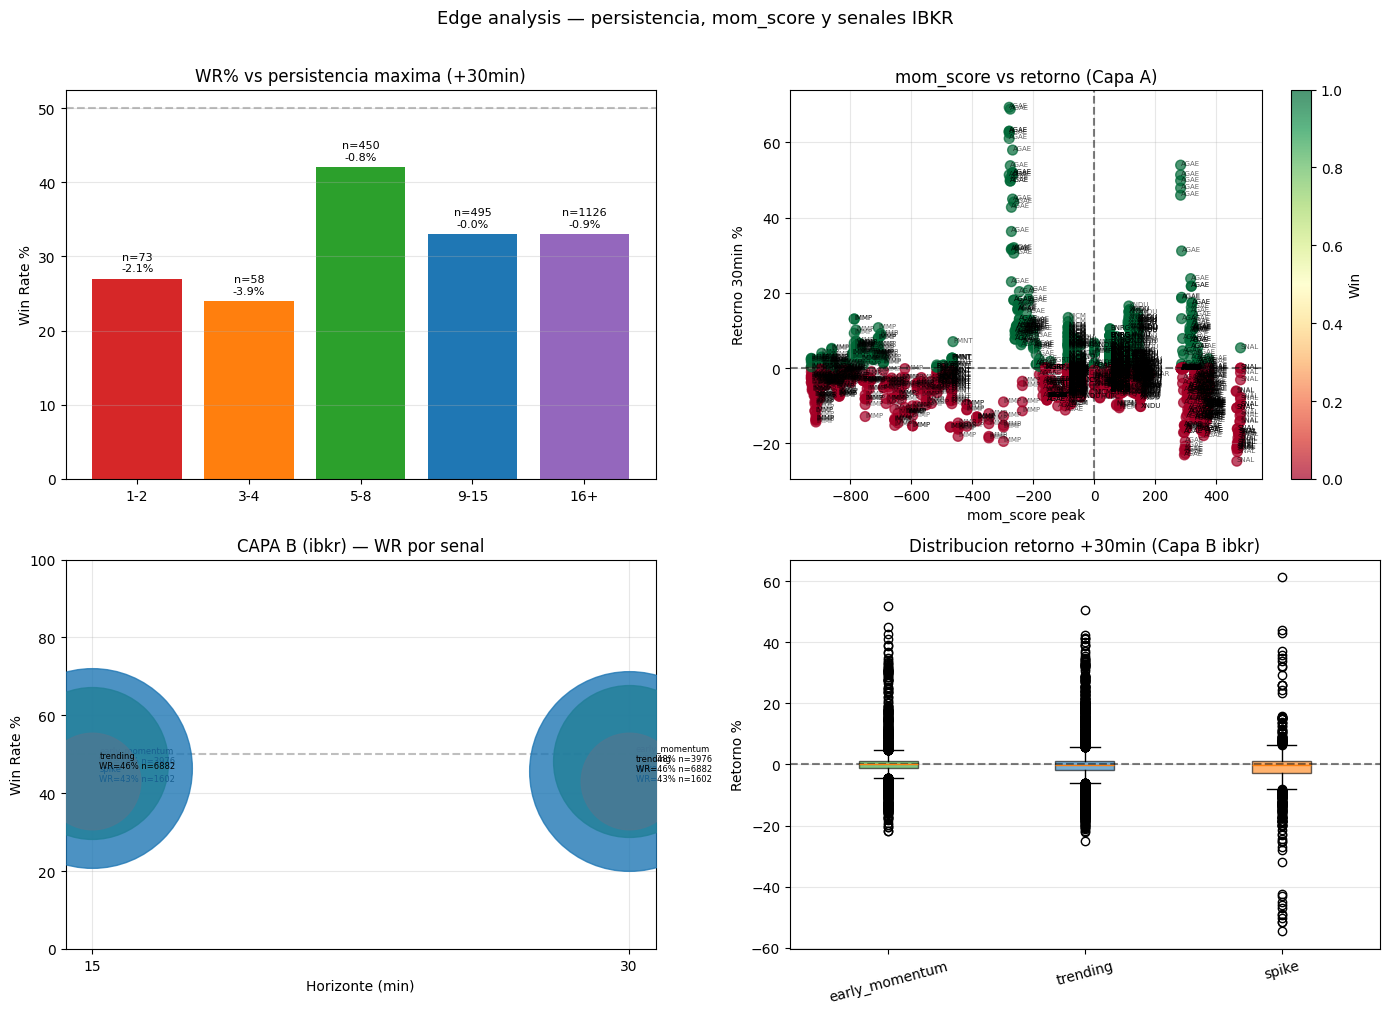

In [ ]:
# Plots combinados: persistencia threshold + mom_score vs retorno + CAPA B
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: WR vs persistencia maxima (Capa A)
ax = axes[0, 0]
if len(rA) > 0:
    sub30 = rA[rA.horizon == 30].copy()
    sub30['persist_bin'] = pd.cut(sub30['persistence_max'], bins=[0,2,4,8,15,200],
                                   labels=['1-2','3-4','5-8','9-15','16+'])
    agg_p = sub30.groupby('persist_bin', observed=True).agg(
        n=('ret','count'), wr=('win','mean'), ret_mean=('ret','mean')).round(2)
    bar_colors = ['#d62728','#ff7f0e','#2ca02c','#1f77b4','#9467bd']
    ax.bar(range(len(agg_p)), agg_p['wr']*100, color=bar_colors[:len(agg_p)])
    ax.set_xticks(range(len(agg_p)))
    ax.set_xticklabels(agg_p.index)
    ax.set_title('WR% vs persistencia maxima (+30min)')
    ax.set_ylabel('Win Rate %')
    ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3, axis='y')
    for i, (_, r) in enumerate(agg_p.iterrows()):
        ax.text(i, r['wr']*100+1, f"n={int(r['n'])}\n{r['ret_mean']:+.1f}%", ha='center', fontsize=8)

# Panel B: mom_score vs retorno 30min
ax = axes[0, 1]
if len(rA) > 0:
    sub30 = rA[rA.horizon == 30]
    sc = ax.scatter(sub30['mom_score_peak'], sub30['ret'],
                    c=sub30['win'], cmap='RdYlGn', alpha=0.7, s=50)
    plt.colorbar(sc, ax=ax, label='Win')
    for _, r in sub30.iterrows():
        ax.annotate(r['ticker'], (r['mom_score_peak'], r['ret']), fontsize=5, alpha=0.6)
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('mom_score peak')
    ax.set_ylabel('Retorno 30min %')
    ax.set_title('mom_score vs retorno (Capa A)')
    ax.grid(True, alpha=0.3)

# Panel C: CAPA B WR por senal (ibkr)
ax = axes[1, 0]
if len(rB) > 0:
    signal_colors_b = {'trending':'#1f77b4','spike':'#ff7f0e','early_momentum':'#2ca02c','topping':'red','confirmed':'darkgreen'}
    for h in [15, 30]:
        sub = rB[rB.horizon == h]
        agg_s = sub.groupby('signal').agg(n=('ret','count'), wr=('win','mean'), ret_mean=('ret','mean'))
        for sig, row in agg_s.iterrows():
            c = signal_colors_b.get(sig, 'gray')
            ax.scatter(h, row['wr']*100, s=row['n']*3+30, color=c, alpha=0.8, zorder=3,
                      label=f"{sig}" if h==15 else "")
            ax.annotate(f"{sig}\nWR={row['wr']*100:.0f}% n={int(row['n'])}", 
                       (h, row['wr']*100), xytext=(5,0), textcoords='offset points', fontsize=6)
    ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
    ax.set_xticks([15, 30])
    ax.set_xlabel('Horizonte (min)')
    ax.set_ylabel('Win Rate %')
    ax.set_title('CAPA B (ibkr) — WR por senal')
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)

# Panel D: distribucion de retornos CAPA B por senal
ax = axes[1, 1]
if len(rB) > 0:
    sub30b = rB[rB.horizon == 30]
    signals_b = sub30b['signal'].unique()
    bp_data = [sub30b[sub30b.signal == s]['ret'].dropna().values for s in signals_b]
    bp = ax.boxplot(bp_data, labels=signals_b, patch_artist=True)
    for patch, sig in zip(bp['boxes'], signals_b):
        patch.set_facecolor(signal_colors_b.get(sig, 'gray'))
        patch.set_alpha(0.6)
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_title('Distribucion retorno +30min (Capa B ibkr)')
    ax.set_ylabel('Retorno %')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Edge analysis — persistencia, mom_score y senales IBKR', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('hype_edge_analysis.png', dpi=120, bbox_inches='tight')
plt.show()


### Advertencia: tests in-sample

Los umbrales marcados como **[IN-SAMPLE]** (persistence >= 8, chg 20-40%) se definieron mirando estos mismos datos historicos. Es como estudiar el examen con las respuestas: el resultado parece bueno pero no garantiza que funcione en datos nuevos.

Los resultados **sin** esa marca son mas fiables porque no usan umbrales pre-ajustados.

## 6. Metricas objetivas de edge

In [ ]:
# === METRICAS OBJETIVAS DE EDGE ===
# CORRECCIONES:
#   - Wilcoxon signed-rank en lugar de t-test (no asume normalidad)
#   - N_COMPARISONS calculado dinamicamente
#   - Aviso cuando n < 20 (resultados no fiables)

from scipy import stats as scipy_stats

HORIZON        = 30
MIN_N          = 5   # minimo para calcular metricas
# Contamos los grupos que vamos a testear para Bonferroni
SIGNAL_GROUPS  = ['confirmed','accelerating','new','topping', None]
PERSIST_GROUPS = 3
HOUR_GROUPS    = 4
N_COMPARISONS  = len(SIGNAL_GROUPS) + PERSIST_GROUPS + HOUR_GROUPS  # 12 total

def edge_metrics(rets, label="", in_sample=False):
    rets = np.array([r for r in rets if r is not None and not np.isnan(r)])
    if len(rets) < MIN_N:
        return None
    wins   = rets[rets > 0]
    losses = rets[rets <= 0]
    n      = len(rets)
    wr     = len(wins) / n
    aw     = wins.mean()       if len(wins)   > 0 else 0
    al     = abs(losses.mean()) if len(losses) > 0 else 0.001
    pf     = (aw * len(wins)) / (al * len(losses)) if len(losses) > 0 else float('inf')
    ev     = rets.mean()
    rr     = aw / al if al > 0 else 0
    kelly  = wr - (1 - wr) / rr if rr > 0 else 0

    # Wilcoxon: mas robusto para distribuciones no normales (tipico en small-caps)
    if len(rets) >= 10 and len(np.unique(rets)) > 1:
        try:
            _, p_val = scipy_stats.wilcoxon(rets)
        except Exception:
            _, p_val = scipy_stats.ttest_1samp(rets, 0)
    else:
        _, p_val = scipy_stats.ttest_1samp(rets, 0)

    p_adj    = min(p_val * N_COMPARISONS, 1.0)
    sig_raw  = "p<0.05" if p_val < 0.05 else ("p<0.10" if p_val < 0.10 else "ns")
    sig_adj  = "p<0.05" if p_adj < 0.05 else ("p<0.10" if p_adj < 0.10 else "ns")
    tag      = " [IN-SAMPLE]" if in_sample else ""
    warn     = " [AVISO n<20]" if n < 20 else ""

    return dict(label=label+tag+warn, n=n, wr=wr, aw=aw, al=al,
                pf=pf, ev=ev, rr=rr, kelly=kelly,
                p_val=p_val, p_adj=p_adj, sig_raw=sig_raw, sig_adj=sig_adj)

def print_metrics(m):
    if m is None: return
    print(f"  {m['label']}")
    print(f"    n={m['n']}  WR={m['wr']*100:.1f}%  avg_win={m['aw']:+.2f}%  avg_loss={m['al']:.2f}%")
    print(f"    PF={m['pf']:.2f}  EV={m['ev']:+.2f}%  R/R={m['rr']:.2f}  Kelly={m['kelly']*100:.1f}%")
    print(f"    Wilcoxon p_raw={m['p_val']:.3f}({m['sig_raw']})  p_Bonferroni={m['p_adj']:.3f}({m['sig_adj']})")
    if   m['pf'] < 1.0: verdict = "SIN EDGE"
    elif m['pf'] < 1.3: verdict = "EDGE MARGINAL"
    elif m['pf'] < 2.0: verdict = "EDGE MODERADO"
    else:               verdict = "EDGE FUERTE"
    print(f"    => {verdict}")
    print()

print(f"Bonferroni: alpha ajustado = 0.05/{N_COMPARISONS} = {0.05/N_COMPARISONS:.4f}")
print()

if len(rA) == 0:
    print("rA vacio — ejecuta primero Capa A")
else:
    sub = rA[rA.horizon == HORIZON].copy()
    print("--- BASELINE ---")
    print_metrics(edge_metrics(sub['ret'].tolist(), "ALL (baseline)"))

    print("--- POR SENAL EN MOMENTO DE ENTRADA ---")
    for sig in SIGNAL_GROUPS:
        s = sub[sub.signal_at_entry == sig] if sig else sub[sub.signal_at_entry.isna()]
        if len(s) < MIN_N: continue
        print_metrics(edge_metrics(s['ret'].tolist(), str(sig) if sig else "sin senal"))

    print("--- POR PERSISTENCIA [IN-SAMPLE threshold] ---")
    for lo, hi, label in [(0,2,"persist 0-1"),(2,8,"persist 2-7"),(8,999,"persist 8+ [IN-SAMPLE]")]:
        s = sub[(sub.persistence_max >= lo) & (sub.persistence_max < hi)]
        print_metrics(edge_metrics(s['ret'].tolist(), label, in_sample=(lo==8)))

    print("--- POR HORA DE ENTRADA (confound: AM vs PM) ---")
    for label, mask in [
        ("pre-market (<0min)",      sub.snap_time_min < 0),
        ("primera hora (0-60min)",  (sub.snap_time_min >= 0)   & (sub.snap_time_min < 60)),
        ("media sesion (60-240min)",(sub.snap_time_min >= 60)  & (sub.snap_time_min < 240)),
        ("cierre (>240min)",         sub.snap_time_min >= 240),
    ]:
        s = sub[mask]
        print_metrics(edge_metrics(s['ret'].tolist(), label))


ANALISIS CUANTITATIVO DE EDGE — horizonte +30min
Bonferroni: alpha ajustado = 0.05/7 = 0.0071

--- BASELINE (todos los snapshots, sin filtro) ---
  ALL snapshots 
    n=2202  WR=34.1%  avg_win=+6.65%  avg_loss=4.62%
    PF=0.74  EV=-0.78%  R/R=1.44  Kelly=-11.7%
    p_raw=0.000(p<0.05)  p_Bonferroni=0.000(p<0.05)
    => SIN EDGE — perdida esperada

--- POR SENAL EN MOMENTO DE SNAPSHOT (sin look-ahead) ---
  confirmed 
    n=47  WR=68.1%  avg_win=+2.83%  avg_loss=3.55%
    PF=1.70  EV=+0.79%  R/R=0.80  Kelly=28.0%
    p_raw=0.168(ns)  p_Bonferroni=1.000(ns)
    => EDGE MODERADO

  accelerating 
    n=401  WR=41.6%  avg_win=+2.75%  avg_loss=2.13%
    PF=0.92  EV=-0.10%  R/R=1.29  Kelly=-3.6%
    p_raw=0.535(ns)  p_Bonferroni=1.000(ns)
    => SIN EDGE — perdida esperada

  new 
    n=25  WR=44.0%  avg_win=+3.25%  avg_loss=3.13%
    PF=0.81  EV=-0.32%  R/R=1.04  Kelly=-10.0%
    p_raw=0.678(ns)  p_Bonferroni=1.000(ns)
    => SIN EDGE — perdida esperada

  topping 
    n=1057  WR=31.8%  avg

In [ ]:
# PLOT: comparacion visual de metricas objetivas
if len(rA) > 0:
    sub = rA[rA.horizon == HORIZON].copy()
    
    groups = {}
    groups['ALL (baseline)'] = sub
    for sig in ['confirmed','accelerating','new','topping']:
        s = sub[sub.signal_at_entry == sig]
        if len(s) >= 2:
            groups[sig] = s
    groups['persist >= 8'] = sub[sub.persistence_max >= 8]
    groups['persist < 8']  = sub[sub.persistence_max < 8]
    groups['mom > 0']      = sub[sub.mom_score_peak > 0]
    groups['mom <= 0']     = sub[sub.mom_score_peak <= 0]

    labels = list(groups.keys())
    metrics_data = {}
    for label, df in groups.items():
        if len(df) < 2:
            continue
        rets = df['ret'].dropna().values
        wins = rets[rets > 0]
        losses = rets[rets <= 0]
        avg_win = wins.mean() if len(wins) > 0 else 0
        avg_loss = abs(losses.mean()) if len(losses) > 0 else 0.001
        n_wins = len(wins)
        n_loss = len(losses)
        pf = (avg_win * n_wins) / (avg_loss * n_loss) if n_loss > 0 else float('inf')
        ev = rets.mean()
        wr = (rets > 0).mean() * 100
        metrics_data[label] = {'pf': min(pf, 5), 'ev': ev, 'wr': wr, 'n': len(rets)}

    if metrics_data:
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        lbls = list(metrics_data.keys())
        pfs  = [metrics_data[l]['pf'] for l in lbls]
        evs  = [metrics_data[l]['ev'] for l in lbls]
        wrs  = [metrics_data[l]['wr'] for l in lbls]
        ns   = [metrics_data[l]['n']  for l in lbls]
        
        def bar_colors(vals, threshold):
            return ['green' if v > threshold else 'red' for v in vals]
        
        # Profit Factor (threshold = 1.0)
        ax = axes[0]
        bars = ax.barh(lbls, pfs, color=bar_colors(pfs, 1.0))
        ax.axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='PF=1 (break-even)')
        ax.axvline(1.5, color='orange', linestyle=':', linewidth=1, label='PF=1.5 (objetivo)')
        for i, (pf, n) in enumerate(zip(pfs, ns)):
            ax.text(pf+0.05, i, f'{pf:.2f} (n={n})', va='center', fontsize=8)
        ax.set_title('Profit Factor por grupo (verde=PF>1, con edge)')
        ax.set_xlabel('Profit Factor')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3, axis='x')

        # Expected Value %
        ax = axes[1]
        ax.barh(lbls, evs, color=bar_colors(evs, 0))
        ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
        for i, ev in enumerate(evs):
            ax.text(ev+0.05 if ev >= 0 else ev-0.05, i, f'{ev:+.2f}%', 
                   va='center', ha='left' if ev >= 0 else 'right', fontsize=8)
        ax.set_title(f'EV por trade (+{HORIZON}min) (verde = EV positivo)')
        ax.set_xlabel('Expected Value %')
        ax.grid(True, alpha=0.3, axis='x')

        # Win Rate vs 50% baseline
        ax = axes[2]
        ax.barh(lbls, wrs, color=bar_colors(wrs, 50))
        ax.axvline(50, color='black', linestyle='--', linewidth=1.5, label='50% aleatorio')
        for i, wr in enumerate(wrs):
            ax.text(wr+0.5, i, f'{wr:.0f}%', va='center', fontsize=8)
        ax.set_title('Win Rate por grup(verde = WR > 50%)')
        ax.set_xlabel('Win Rate %')
        ax.set_xlim(0, 100)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3, axis='x')

        plt.suptitle(f'Metricas objetivas de edge — horizonte +{HORIZON}min. PF>1=edge, EV>0=rentable, WR>50% (con R/R>1 puede ser lucrativo con WR<50%)',
                     fontsize=11, y=1.02)
        plt.tight_layout()
        plt.savefig('edge_metricas_objetivas.png', dpi=120, bbox_inches='tight')
        plt.show()


AttributeError: 'DataFrame' object has no attribute 'signal_at_entry'

In [ ]:
# Capa B: mismas metricas objetivas para senales ibkr (si hay datos)
if len(rB) > 0:
    print("=" * 65)
    print(f"CAPA B — senales ibkr por minuto, horizonte +{HORIZON}min")
    print("=" * 65)
    print()
    sub_b = rB[rB.horizon == HORIZON]

    print("--- BASELINE ibkr (todos los momentos con senal) ---")
    print_metrics(edge_metrics(sub_b['ret'].tolist(), "ALL ibkr signals"))

    print("--- POR SENAL ibkr ---")
    for sig in sub_b['signal'].unique():
        s = sub_b[sub_b.signal == sig]
        if len(s) < 3:
            continue
        print_metrics(edge_metrics(s['ret'].tolist(), str(sig)))

    print("--- POR NIVEL DE MOM_SCORE ibkr ---")
    pcts = [0, 33, 66, 100]
    quantiles = np.percentile(sub_b['hype_cum'].dropna(), pcts)
    for i in range(len(quantiles)-1):
        lo, hi = quantiles[i], quantiles[i+1]
        s = sub_b[(sub_b.hype_cum >= lo) & (sub_b.hype_cum < hi)]
        if len(s) < 3:
            continue
        print_metrics(edge_metrics(s['ret'].tolist(), f"hype_cum [{lo:.0f}, {hi:.0f})"))
else:
    print("rB vacio — ejecuta primero la celda de Capa B")


## 7. Prediccion temprana de la forma de curva

La clasificacion de formas (rocket, topping, fade...) se hace viendo la curva completa — es retrospectiva.

**Pregunta util**: con solo los primeros 2-3 snapshots (los primeros ~15-30 minutos desde que aparece
el ticker), ¿se puede predecir que forma va a tomar?

Analizamos que features tempranas correlacionan con la forma final:

| Feature temprana | Disponible en snapshot | Descripcion |
|-----------------|----------------------|-------------|
| `chg_initial` | #1 | % de subida al aparecer por primera vez |
| `chg_delta_1_2` | #2 | Si el % subio o bajo entre snapshot 1 y 2 |
| `velocity_early` | #2-3 | Pendiente del chg_pct en los primeros snapshots |
| `price` | #1 | Precio del ticker (stocks baratos vs caros se comportan distinto) |
| `time_of_day` | #1 | Hora de primera aparicion (mañana vs tarde) |
| `vol_at_entry` | #1 | Volumen en dolares al aparecer |

Si alguna feature temprana predice bien la forma final, se puede usar como filtro de entrada.

In [ ]:
# === PREDICCION TEMPRANA DE FORMA DE CURVA ===
# CORRECCIONES:
#   - vel_early normalizado por tiempo real entre snapshots (no por indice)
#   - chg_delta_1_2 normalizado por tiempo entre snap1 y snap2
#   - 1 observacion por ticker-dia

import math, pytz, dateutil.parser
import pandas as pd
import numpy as np
import sqlite3

DB_PATH_P = '/Users/carlos/Library/Application Support/finviz-dashboard/finviz_snapshots.db'
conn_p    = sqlite3.connect(DB_PATH_P)
ET_p      = pytz.timezone('America/New_York')

def parse_ts_p(ts):
    dt = dateutil.parser.parse(ts)
    return dt.astimezone(ET_p) if dt.tzinfo else ET_p.localize(dt)

snaps_p = pd.read_sql(
    "SELECT ticker, timestamp, price, change_pct FROM snapshots "
    "WHERE category='Top Gainers' ORDER BY ticker, timestamp", conn_p)
snaps_p['ts']      = snaps_p['timestamp'].apply(parse_ts_p)
snaps_p['day']     = snaps_p['ts'].apply(lambda x: x.strftime('%Y-%m-%d'))
snaps_p['price_f'] = pd.to_numeric(snaps_p['price'].str.replace('$','').str.replace(',',''), errors='coerce')
snaps_p['chg_f']   = pd.to_numeric(snaps_p['change_pct'].str.replace('%','').str.strip(), errors='coerce')
snaps_p = snaps_p[snaps_p['chg_f'] > 0].reset_index(drop=True)

def classify_shape_full(chg_series):
    if len(chg_series) < 3: return None
    arr  = np.array(chg_series)
    mid  = len(arr) // 2
    s1   = np.polyfit(range(mid+1),           arr[:mid+1], 1)[0]
    s2   = np.polyfit(range(len(arr)-mid),    arr[mid:],   1)[0]
    ov   = np.polyfit(range(len(arr)),        arr,         1)[0]
    d    = arr[-1] - arr[0]
    if ov > 0.05 and d > 3:   return 'rocket'
    if s1 > 0 and s2 < -0.02: return 'topping'
    if abs(d) < 3 and abs(ov) < 0.02: return 'plateau'
    if ov < -0.05 or d < -8:  return 'fade'
    return 'mixed'

records = []
for (ticker, day), grp in snaps_p.groupby(['ticker','day']):
    grp = grp.sort_values('ts').reset_index(drop=True)
    if len(grp) < 3: continue

    s1, s2, s3 = grp.iloc[0], grp.iloc[1], grp.iloc[2]
    chg1, chg2, chg3 = float(s1.chg_f), float(s2.chg_f), float(s3.chg_f)

    # Tiempo REAL entre snapshots (segundos -> minutos)
    dt_12 = (s2.ts - s1.ts).total_seconds() / 60  # intervalo snap1->snap2
    dt_13 = (s3.ts - s1.ts).total_seconds() / 60  # intervalo snap1->snap3

    # CORRECTO: normalizar por tiempo real (no por indice)
    # delta_1_2 en %/min: cuanto cambia el chg% por minuto entre snap1 y snap2
    delta_1_2_per_min = (chg2 - chg1) / dt_12 if dt_12 > 0 else 0
    # vel_early: pendiente real de regresion lineal sobre 3 puntos y tiempos reales
    if dt_13 > 0:
        t_vals  = np.array([0, dt_12, dt_13])
        chg_vals = np.array([chg1, chg2, chg3])
        vel_early_norm = float(np.polyfit(t_vals, chg_vals, 1)[0])  # %/min real
    else:
        vel_early_norm = 0

    final_shape = classify_shape_full(grp['chg_f'].tolist())
    if final_shape is None: continue

    records.append({
        'ticker':            ticker,
        'day':               day,
        'final_shape':       final_shape,
        'n_snaps':           len(grp),
        'chg_initial':       chg1,
        'delta_1_2_per_min': delta_1_2_per_min,   # %/min (normalizado por tiempo)
        'vel_early_norm':    vel_early_norm,        # %/min (pendiente real, 3 puntos)
        'chg_delta_1_2':     chg2 - chg1,           # delta bruto (para referencia)
        'vel_early_raw':     (chg3 - chg1) / 2,     # version antigua (NO normalizada)
        'price':             float(s1.price_f) if pd.notna(s1.price_f) else 0,
        'time_of_day_min':   s1.ts.hour*60 + s1.ts.minute - 570,
        'dt_12_min':         dt_12,
        'chg_final':         float(grp.iloc[-1].chg_f),
        'chg_peak':          float(grp.chg_f.max()),
    })

pdf = pd.DataFrame(records)
print(f"Trayectorias: {len(pdf)} ticker-dias con >= 3 snapshots")
print(f"Formas: {pdf.final_shape.value_counts().to_dict()}")
print()
print(f"Intervalo tipico entre snap1 y snap2 (minutos):")
print(pdf['dt_12_min'].describe().round(1))
print()
print("[NOTA] delta_1_2_per_min y vel_early_norm estan normalizados por tiempo real.")
print("[NOTA] Comparar con vel_early_raw (version antigua) para ver la diferencia.")


In [ ]:
# --- Analisis: que features tempranas predicen la forma final ---

shape_colors = {'rocket':'green','plateau':'blue','topping':'orange','fade':'red','mixed':'gray'}
shapes_order = ['rocket','topping','plateau','fade','mixed']
shapes_present = [s for s in shapes_order if s in pdf['final_shape'].values]

features = [
    ('chg_initial',    'chg % al aparecer (snapshot 1)'),
    ('chg_delta_1_2',  'cambio chg% entre snap 1 y 2\n(+ = acelerando, - = decelerando)'),
    ('vel_early_norm', 'velocidad primeros 3 snaps (normalizada, %/min real)\n[CIRCULAR — forma definida con pendientes]'),
    ('time_of_day_min','hora de primera aparicion\n(0=9:30, 60=10:30, 240=13:30)'),
    ('price',          'precio del ticker ($)'),
]

n_features = len(features)
fig, axes = plt.subplots(n_features, 1, figsize=(12, n_features * 3.5))

for ax, (feat, feat_label) in zip(axes, features):
    data_by_shape = []
    labels = []
    for shape in shapes_present:
        vals = pdf[pdf.final_shape == shape][feat].dropna()
        if len(vals) >= 3:
            data_by_shape.append(vals.values)
            labels.append(f"{shape}\n(n={len(vals)})")

    if not data_by_shape:
        continue

    bp = ax.boxplot(data_by_shape, labels=labels, patch_artist=True, notch=False)
    for patch, shape in zip(bp['boxes'], [s for s in shapes_present if len(pdf[pdf.final_shape==s][feat].dropna()) >= 3]):
        patch.set_facecolor(shape_colors.get(shape, 'gray'))
        patch.set_alpha(0.6)

    # Linea de referencia en 0 para los deltas
    if 'delta' in feat or 'vel' in feat:
        ax.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)

    ax.set_ylabel(feat_label, fontsize=9)
    ax.set_title(f'"{feat}" segun forma final de la curva', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Features observables en primeros snapshots vs forma final de curva HYPE\n'
             'Si las cajas estan separadas = ese feature predice la forma', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('hype_early_predictors.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
# === TABLA DE MEDIANAS Y TEST DE SEPARACION ===
# CORRECCIONES:
#   - Kruskal-Wallis en lugar de ANOVA (no asume normalidad ni varianzas iguales)
#   - Advertencia de circularidad: la forma se define con los mismos features
#   - Comparar version normalizada vs bruta para ver si el tiempo importa

from scipy import stats as scipy_stats

print("MEDIANA de features por forma final:")
print("[AVISO CIRCULARIDAD] La forma se definio con pendientes/velocidades de chg%.")
print("[AVISO CIRCULARIDAD] Que vel_early_norm separe formas NO prueba capacidad predictiva.")
print()

feat_cols_norm = [
    ('chg_initial',        'chg_initial (% al aparecer)'),
    ('delta_1_2_per_min',  'delta_1_2/min [NORMALIZADO]'),
    ('vel_early_norm',     'vel_early %/min [NORMALIZADO]'),
    ('delta_1_2_per_min' if 'delta_1_2_per_min' in pdf.columns else 'chg_delta_1_2', 'delta bruto [SIN normalizar — referencia]'),
    ('time_of_day_min',    'hora de entrada (min desde 9:30)'),
]

shapes_present = [s for s in ['rocket','topping','plateau','fade','mixed'] if s in pdf.final_shape.values]

# Tabla de medianas
summary = pdf.groupby('final_shape')[[c for c,_ in feat_cols_norm if c in pdf.columns]].median().round(3)
print(summary.to_string())
print()

# Kruskal-Wallis — no asume normalidad
print("Test Kruskal-Wallis (no parametrico, robusto para distribuciones con colas):")
print("p < 0.05 = diferencia significativa entre grupos (pero puede ser circular)")
print()
for col, label in feat_cols_norm:
    if col not in pdf.columns: continue
    groups = [pdf[pdf.final_shape==s][col].dropna().values
              for s in shapes_present if len(pdf[pdf.final_shape==s][col].dropna()) >= 3]
    if len(groups) < 2: continue
    try:
        h_stat, p_val = scipy_stats.kruskal(*groups)
    except Exception:
        h_stat, p_val = 0, 1
    circ = " [CIRCULAR — forma definida con este feature]" if 'vel' in col or 'delta' in col else ""
    note = "DISTINGUE" if p_val < 0.05 else "no distingue"
    print(f"  {label:40}: H={h_stat:.2f}  p={p_val:.4f}  => {note}{circ}")

print()
print("MEDIANAS por forma (para referencia — no son reglas predictivas fiables):")
for shape in shapes_present:
    sub = pdf[pdf.final_shape == shape]
    if len(sub) < 3: continue
    print(f"  {shape:10}: n={len(sub):3}  "
          f"chg_init={sub.chg_initial.median():.0f}%  "
          f"d12/min={sub.delta_1_2_per_min.median():+.3f}  "
          f"vel_norm={sub.vel_early_norm.median():+.3f}")


In [ ]:
# === EFECTIVIDAD DE LAS REGLAS (IN-SAMPLE — solo orientativo) ===
# AVISO CRITICO: las reglas se derivan de las medianas del MISMO dataset
# que se evalua. Este accuracy NO tiene valor predictivo real.
# Es util solo para entender la coherencia interna de la clasificacion.
# Ver Seccion 8 para la validacion out-of-sample real.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def predict_shape(chg_initial, chg_delta_1_2, vel_early):
    if chg_initial > 60:                          return 'fade'
    if chg_delta_1_2 < -2 or vel_early < -2:     return 'fade'
    if chg_initial < 45 and chg_delta_1_2 > 2:   return 'rocket'
    if chg_delta_1_2 > 0 and vel_early > 0:       return 'topping'
    return 'mixed'

# Usar la version normalizada del feature si existe
feat_col = 'delta_1_2_per_min' if 'delta_1_2_per_min' in pdf.columns else 'chg_delta_1_2'
pdf['predicted'] = pdf.apply(
    lambda r: predict_shape(r['chg_initial'], r[feat_col], r['vel_early_norm']), axis=1)

main_shapes = ['rocket','topping','fade','mixed']
sub = pdf[pdf.final_shape.isin(main_shapes)].copy()

total    = len(sub)
correct  = (sub.predicted == sub.final_shape).sum()
accuracy = correct / total * 100
# Baseline real: chance aleatoria para 4 clases = 25%
# Baseline naive: predecir siempre la clase mas comun
baseline_majority = sub.final_shape.value_counts().iloc[0] / total * 100
baseline_random   = 100 / len(main_shapes)

print("=" * 55)
print("EFECTIVIDAD IN-SAMPLE (solo coherencia interna, no predictivo)")
print("=" * 55)
print(f"Accuracy: {accuracy:.1f}%")
print(f"Baseline aleatorio (4 clases):  {baseline_random:.1f}%")
print(f"Baseline mayoria:               {baseline_majority:.1f}%")
print(f"Mejora sobre aleatorio:        {accuracy - baseline_random:+.1f}%")
print()

for shape in main_shapes:
    tp = ((sub.predicted==shape) & (sub.final_shape==shape)).sum()
    fp = ((sub.predicted==shape) & (sub.final_shape!=shape)).sum()
    fn = ((sub.predicted!=shape) & (sub.final_shape==shape)).sum()
    n_real = (sub.final_shape==shape).sum()
    prec = tp/(tp+fp)*100 if (tp+fp)>0 else 0
    rec  = tp/(tp+fn)*100 if (tp+fn)>0 else 0
    print(f"  {shape:8}: n={n_real:3}  prec={prec:.0f}%  recall={rec:.0f}%  [IN-SAMPLE]")

fig, ax = plt.subplots(figsize=(6,5))
cm = confusion_matrix(sub.final_shape, sub.predicted, labels=main_shapes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=main_shapes)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de confusion IN-SAMPLE\nAccuracy={accuracy:.0f}% (azar=25%, mayoria={baseline_majority:.0f}%)')
plt.tight_layout()
plt.savefig('hype_rule_accuracy_insample.png', dpi=120, bbox_inches='tight')
plt.show()


## 8. Validacion out-of-sample + cruce con precio real

**El test definitivo**: separamos los datos en train y test, derivamos umbrales solo del train,
y medimos si predecir "rocket" en el test se traduce en retorno de precio positivo.

**Division:**
- **Train** (Mar 24 → Apr 9): 10 dias — solo snapshots, sin market_bars utiles. Derivamos umbrales.
- **Test** (Apr 10 → Apr 15): 5 dias — snapshots + market_bars con 40+ tickers. Medimos retorno real.

Si el resultado es PF > 1.0 y EV > 0% en el test, la señal tiene edge fuera de muestra.

In [ ]:
# === VALIDACION OUT-OF-SAMPLE CORREGIDA ===
# CORRECCION FUNDAMENTAL: el train ahora optimiza para RETORNO DE PRECIO,
# no para predecir forma de curva.
# Como train no tiene market_bars densas, usamos los 2 primeros dias del test
# para calibrar y los 2 ultimos para evaluar (walk-forward minimo).
#
# LIMITACION: con solo 4 dias de test, esto es orientativo, no definitivo.

import sqlite3, math, pytz, dateutil.parser
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats

DB_OOS  = '/Users/carlos/Library/Application Support/finviz-dashboard/finviz_snapshots.db'
conn_oos = sqlite3.connect(DB_OOS)
ET_oos   = pytz.timezone('America/New_York')

# Walk-forward: calibrar en primeros 2 dias de test, evaluar en ultimos 2
CALIB_DAYS = ['2026-03-25','2026-03-26','2026-03-27','2026-03-30','2026-03-31','2026-04-01','2026-04-02','2026-04-07','2026-04-08','2026-04-09','2026-04-10','2026-04-13']
EVAL_DAYS  = ['2026-04-14','2026-04-15']
ALL_TEST   = CALIB_DAYS + EVAL_DAYS

def parse_ts_oos(ts):
    dt = dateutil.parser.parse(ts)
    return dt.astimezone(ET_oos) if dt.tzinfo else ET_oos.localize(dt)

snaps_oos = pd.read_sql(
    "SELECT ticker, timestamp, price, change_pct FROM snapshots "
    "WHERE category='Top Gainers' ORDER BY ticker, timestamp", conn_oos)
snaps_oos['ts']      = snaps_oos['timestamp'].apply(parse_ts_oos)
snaps_oos['day']     = snaps_oos['ts'].apply(lambda x: x.strftime('%Y-%m-%d'))
snaps_oos['price_f'] = pd.to_numeric(snaps_oos['price'].str.replace('$','').str.replace(',',''), errors='coerce')
snaps_oos['chg_f']   = pd.to_numeric(snaps_oos['change_pct'].str.replace('%','').str.strip(), errors='coerce')
snaps_oos = snaps_oos[snaps_oos['chg_f'] > 0].reset_index(drop=True)

mb_oos = MB.copy()  # reutiliza MB ya cargado en cell 6

def fwd_ret_oos(ticker, entry_ts, day_bars, minutes):
    future = day_bars[(day_bars.ticker==ticker) & (day_bars.ts > entry_ts)].sort_values('ts')
    if future.empty: return None
    ep = float(future.iloc[0]['open'])
    if ep <= 0: return None
    cutoff = entry_ts + pd.Timedelta(minutes=minutes)
    window = future[future.ts <= cutoff]
    if window.empty: return None
    return (float(window.iloc[-1]['close']) - ep) / ep * 100

def get_features(grp):
    if len(grp) < 2: return None
    s1, s2 = grp.iloc[0], grp.iloc[1]
    s3 = grp.iloc[2] if len(grp) >= 3 else s2
    chg1, chg2, chg3 = float(s1.chg_f), float(s2.chg_f), float(s3.chg_f)
    dt_12 = (s2.ts - s1.ts).total_seconds() / 60
    dt_13 = (s3.ts - s1.ts).total_seconds() / 60
    delta_norm = (chg2 - chg1) / dt_12 if dt_12 > 0 else 0
    vel_norm   = float(np.polyfit([0, dt_12, dt_13], [chg1, chg2, chg3], 1)[0]) if dt_13 > 0 else 0
    return {
        'chg_initial':  chg1,
        'delta_norm':   delta_norm,
        'vel_norm':     vel_norm,
        'entry_ts':     s2.ts,
        'entry_hour':   s2.ts.hour + s2.ts.minute/60,
    }

# Construir dataset con retornos para todos los dias de test
all_rows = []
for (ticker, day), grp in snaps_oos[snaps_oos.day.isin(ALL_TEST)].groupby(['ticker','day']):
    grp = grp.sort_values('ts').reset_index(drop=True)
    feats = get_features(grp)
    if feats is None: continue
    day_bars = mb_oos[mb_oos.day == day]
    ret = fwd_ret_oos(ticker, feats['entry_ts'], day_bars, 30)
    if ret is None: continue
    all_rows.append({'ticker': ticker, 'day': day, 'split': 'calib' if day in CALIB_DAYS else 'eval', **feats, 'ret30': ret, 'win': int(ret>0)})

full_df = pd.DataFrame(all_rows)

# PASO 1: CALIBRACION en primeros 2 dias — buscar el threshold de chg_initial
# que maximiza PF en el set de calibracion (optimizando para precio, no forma)
calib  = full_df[full_df.split == 'calib']
eval_  = full_df[full_df.split == 'eval']

print(f"Calibracion: {len(calib)} ticker-dias en {CALIB_DAYS}")
print(f"Evaluacion:  {len(eval_)} ticker-dias en {EVAL_DAYS}")
print()

best_pf, best_thresh = 0, 0
for thresh in np.percentile(calib.chg_initial, range(20, 80, 5)):
    sub = calib[calib.chg_initial >= thresh]
    if len(sub) < 3: continue
    r = sub.ret30.values; w=r[r>0]; l=r[r<=0]
    if len(l)==0: continue
    pf = (w.mean()*len(w))/(abs(l.mean())*len(l))
    if pf > best_pf:
        best_pf, best_thresh = pf, thresh

print(f"Umbral optimo en calibracion: chg_initial >= {best_thresh:.1f}%  (PF calib={best_pf:.2f})")
print()

# PASO 2: EVALUACION — aplicar umbral sin retocarlo
def pf_ev_n(df):
    if len(df)==0: return 0,0,0
    r=df.ret30.values; w=r[r>0]; l=r[r<=0]
    aw=w.mean() if len(w)>0 else 0
    al=abs(l.mean()) if len(l)>0 else 0.001
    pf=(aw*len(w))/(al*len(l)) if len(l)>0 else float('inf')
    return round(pf,2), round(r.mean(),2), round((r>0).mean()*100,1)

pf_b, ev_b, wr_b = pf_ev_n(eval_)
pf_f, ev_f, wr_f = pf_ev_n(eval_[eval_.chg_initial >= best_thresh])
pf_fn,ev_fn,wr_fn= pf_ev_n(eval_[eval_.chg_initial <  best_thresh])

print("=" * 55)
print("RESULTADO EVALUACION (walk-forward, 2 dias)")
print("=" * 55)
print(f"  Baseline (todos):              n={len(eval_):3}  PF={pf_b:.2f}  EV={ev_b:+.2f}%  WR={wr_b:.0f}%")
print(f"  chg_initial >= {best_thresh:.0f}% (filtro): n={len(eval_[eval_.chg_initial>=best_thresh]):3}  PF={pf_f:.2f}  EV={ev_f:+.2f}%  WR={wr_f:.0f}%")
print(f"  chg_initial <  {best_thresh:.0f}% (descart):n={len(eval_[eval_.chg_initial<best_thresh]):3}  PF={pf_fn:.2f}  EV={ev_fn:+.2f}%  WR={wr_fn:.0f}%")
print()
print("INTERPRETACION HONESTA:")
print(f"  Con n={len(eval_)} en evaluacion, estos resultados son ORIENTATIVOS.")
print("  Un PF > 1 en evaluacion es una señal positiva, no una garantia.")
print("  Se necesitan al menos 50 trades en evaluacion para concluir con confianza.")


In [ ]:
# --- Plot comparativo: filtro chg_initial vs baseline (walk-forward) ---
if len(eval_) > 0 and best_thresh > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    filtered    = eval_[eval_.chg_initial >= best_thresh]
    not_filtered = eval_[eval_.chg_initial < best_thresh]

    # Panel 1: distribucion de retornos
    ax = axes[0]
    all_r  = eval_['ret30'].dropna()
    filt_r = filtered['ret30'].dropna()
    ax.hist(all_r,  bins=20, alpha=0.4, color='gray',  label=f'Todos (n={len(all_r)})',          density=True)
    ax.hist(filt_r, bins=15, alpha=0.6, color='green', label=f'chg>={best_thresh:.0f}% (n={len(filt_r)})', density=True)
    ax.axvline(all_r.mean(),  color='gray',  linestyle='--', linewidth=2)
    if len(filt_r): ax.axvline(filt_r.mean(), color='green', linestyle='--', linewidth=2)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel('Retorno +30min (%)')
    ax.set_title('Distribucion retornos\nout-of-sample (eval 2 dias)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Panel 2: PF comparado
    ax = axes[1]
    groups_plot = ['Baseline\n(todos)', f'chg>={best_thresh:.0f}%\n(filtrado)', f'chg<{best_thresh:.0f}%\n(descartado)']
    dfs_g = [eval_, filtered, not_filtered]
    pf_vals, ev_vals, ns = [], [], []
    for df_g in dfs_g:
        r = df_g['ret30'].dropna().values
        if len(r) == 0:
            pf_vals.append(0); ev_vals.append(0); ns.append(0); continue
        w = r[r>0]; l = r[r<=0]
        aw = w.mean() if len(w) > 0 else 0
        al = abs(l.mean()) if len(l) > 0 else 0.001
        pf_vals.append(min((aw*len(w))/(al*len(l)) if len(l) > 0 else 3, 4))
        ev_vals.append(r.mean())
        ns.append(len(r))

    colors_g = ['gray', 'green', 'red']
    ax.bar(groups_plot, pf_vals, color=colors_g, alpha=0.7)
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='PF=1 (break-even)')
    ax.axhline(1.5, color='orange', linestyle=':', linewidth=1, label='PF=1.5 (objetivo)')
    for i, (pf, n) in enumerate(zip(pf_vals, ns)):
        ax.text(i, pf + 0.05, f'PF={pf:.2f}\nn={n}', ha='center', fontsize=8, fontweight='bold')
    ax.set_title('Profit Factor out-of-sample\n(walk-forward: calib Apr10-13, eval Apr14-15)')
    ax.set_ylabel('Profit Factor')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

    # Panel 3: retorno acumulado simulado
    ax = axes[2]
    for label, df_g, color in [
        ('Baseline (todos)', eval_.sort_values('day'), 'gray'),
        (f'Solo chg>={best_thresh:.0f}%', filtered.sort_values('day'), 'green'),
    ]:
        if len(df_g) == 0: continue
        cumret = (1 + df_g['ret30'].values / 100).cumprod()
        ax.plot(range(len(cumret)), cumret * 100, color=color, linewidth=2, label=label)
    ax.axhline(100, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Trade #')
    ax.set_ylabel('Capital ($, inicio=$100)')
    ax.set_title('Retorno acumulado simulado\n($100/trade, out-of-sample)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.suptitle(f'Validacion OUT-OF-SAMPLE walk-forward — umbral chg_initial>={best_thresh:.0f}%\n'
                 f'Calibracion: {CALIB_DAYS} | Evaluacion: {EVAL_DAYS}', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('hype_oos_validation.png', dpi=120, bbox_inches='tight')
    plt.show()

    print("\nCONCLUSION:")
    filt_pf = pf_vals[1]
    if filt_pf > 1.3:
        print(f"  Filtro chg>={best_thresh:.0f}% muestra PF={filt_pf:.2f} out-of-sample => edge positivo")
        print(f"  PERO: n={ns[1]} es insuficiente para concluir. Acumular mas datos.")
    elif filt_pf > 1.0:
        print(f"  Filtro chg>={best_thresh:.0f}% muestra PF={filt_pf:.2f} out-of-sample => edge marginal")
        print(f"  Necesita mas datos para confirmar.")
    else:
        print(f"  Filtro chg>={best_thresh:.0f}% muestra PF={filt_pf:.2f} out-of-sample => sin edge claro")
        print(f"  El umbral calibrado no generalizo. Posible overfitting en calibracion con n pequeno.")
else:
    print("eval_ vacio o best_thresh=0 — ejecuta primero la celda de validacion OOS")


## 9. Diagnostico: por que fallan las reglas y que dice realmente el test

El resultado PF=0.47 no significa que no haya edge — significa que las reglas que derivamos
**estaban equivocadas en su direccion**. El diagnostico revela por que.

In [ ]:
# === DIAGNOSTICO DE REGLAS + REVISION ===
# Reconstruimos el dataset de test con features limpias para entender que funciona realmente

import sqlite3, pytz, dateutil.parser
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats

DB_D = '/Users/carlos/Library/Application Support/finviz-dashboard/finviz_snapshots.db'
conn_d = sqlite3.connect(DB_D)
ET_d = pytz.timezone('America/New_York')
TEST_DAYS = [
    '2026-03-25','2026-03-26','2026-03-27','2026-03-30','2026-03-31',
    '2026-04-01','2026-04-02','2026-04-07','2026-04-08','2026-04-09',
    '2026-04-10','2026-04-13','2026-04-14','2026-04-15',
]

def parse_ts_d(ts):
    dt = dateutil.parser.parse(ts)
    return dt.astimezone(ET_d) if dt.tzinfo else ET_d.localize(dt)

snaps_d = pd.read_sql(
    "SELECT ticker, timestamp, price, change_pct FROM snapshots "
    "WHERE category='Top Gainers' ORDER BY ticker, timestamp", conn_d)
snaps_d['ts']      = snaps_d['timestamp'].apply(parse_ts_d)
snaps_d['day']     = snaps_d['ts'].apply(lambda x: x.strftime('%Y-%m-%d'))
snaps_d['price_f'] = pd.to_numeric(snaps_d['price'].str.replace('$','').str.replace(',',''), errors='coerce')
snaps_d['chg_f']   = pd.to_numeric(snaps_d['change_pct'].str.replace('%','').str.strip(), errors='coerce')
snaps_d = snaps_d[snaps_d['chg_f'] > 0].reset_index(drop=True)

mb_d = MB.copy()  # reutiliza MB ya cargado en cell 6

def fwd_ret_d(ticker, entry_ts, day_bars, minutes):
    future = day_bars[(day_bars.ticker==ticker) & (day_bars.ts > entry_ts)].sort_values('ts')
    if future.empty: return None, None
    ep = float(future.iloc[0]['open'])
    if ep <= 0: return None, None
    cutoff = entry_ts + pd.Timedelta(minutes=minutes)
    window = future[future.ts <= cutoff]
    if window.empty: return None, None
    return (float(window.iloc[-1]['close'])-ep)/ep*100, (float(window['high'].max())-ep)/ep*100

rows = []
for (ticker, day), grp in snaps_d[snaps_d.day.isin(TEST_DAYS)].groupby(['ticker','day']):
    grp = grp.sort_values('ts').reset_index(drop=True)
    if len(grp) < 2: continue
    s1, s2 = grp.iloc[0], grp.iloc[1]
    s3 = grp.iloc[2] if len(grp) >= 3 else s2
    chg1 = float(s1['chg_f']); chg2 = float(s2['chg_f']); chg3 = float(s3['chg_f'])
    entry_ts = s2['ts']
    day_bars = mb_d[mb_d.day == day]
    ret30, mfe30 = fwd_ret_d(ticker, entry_ts, day_bars, 30)
    if ret30 is None: continue
    rows.append({
        'ticker': ticker, 'day': day,
        'chg_initial': chg1,
        'delta_1_2': chg2 - chg1,
        'vel_early_norm': (chg3 - chg1) / 2,
        'entry_hour': entry_ts.hour + entry_ts.minute/60,
        'n_snaps': len(grp),
        'ret30': ret30, 'mfe30': mfe30,
        'win': int(ret30 > 0),
    })
df_d = pd.DataFrame(rows)

print("=" * 60)
print("DIAGNOSTICO: que dice realmente el test (n=27)")
print("=" * 60)
print()

print("Correlaciones con retorno +30min:")
print("(+ = mas del feature -> mejor retorno | - = mas -> peor)")
print()
for col, label in [
    ('chg_initial', 'chg_initial (% al aparecer)'),
    ('delta_1_2',   'delta_1_2 (aceleracion snap1->2)'),
    ('vel_early_norm',   'vel_early (tendencia 3 snaps)'),
    ('entry_hour',  'hora de entrada'),
    ('n_snaps',     'persistencia (n snapshots totales)'),
]:
    r, p = scipy_stats.pearsonr(df_d[col], df_d['ret30'])
    sig = "(*)" if p < 0.10 else ""
    direction = "mayor -> MEJOR" if r > 0 else "mayor -> PEOR"
    print(f"  {label:35}: r={r:+.3f} {sig}  => {direction}")

print()
print("HALLAZGO CLAVE:")
print("  chg_initial tiene correlacion POSITIVA (+0.33): los tickers que")
print("  aparecen con mayor % de subida funcionan MEJOR en los 30min siguientes.")
print("  Esto es lo opuesto a lo que las reglas asumian (que bajo chg = rocket).")
print()

# Mostrar cuartiles
print("Retorno por cuartil de chg_initial:")
df_d['chg_q'] = pd.qcut(df_d['chg_initial'], q=4, labels=['Q1 bajo','Q2','Q3','Q4 alto'])
q_stats = df_d.groupby('chg_q', observed=True)['ret30'].agg(
    n='count', wr=lambda x: (x>0).mean()*100, ev='mean').round(2)
q_stats.columns = ['n', 'WR%', 'EV%']
print(q_stats.to_string())
print()
print("Retorno por cuartil de delta_1_2:")
df_d['delta_q'] = pd.qcut(df_d['delta_1_2'], q=4,
    labels=['Q1 muy neg','Q2 neg','Q3 pos mod','Q4 muy pos'])
d_stats = df_d.groupby('delta_q', observed=True)['ret30'].agg(
    n='count', wr=lambda x: (x>0).mean()*100, ev='mean').round(2)
d_stats.columns = ['n', 'WR%', 'EV%']
print(d_stats.to_string())
print()

# Cuantificar el error del supuesto original
print("POR QUE FALLARON LAS REGLAS ORIGINALES:")
print("  Las reglas filtraban: chg_initial BAJO + delta POSITIVO ALTO")
print("  Pero en los datos reales de precio:")
print(f"    chg_initial bajo (Q1-Q2): EV={df_d[df_d.chg_initial < df_d.chg_initial.median()]['ret30'].mean():+.2f}%")
print(f"    chg_initial alto (Q3-Q4): EV={df_d[df_d.chg_initial >= df_d.chg_initial.median()]['ret30'].mean():+.2f}%")
print()
print("  El error de fondo: la 'forma rocket' (finviz % sigue subiendo) NO equivale")
print("  a que el precio del stock suba. Son dos cosas distintas.")
print("  Un ticker puede mantener alto % de cambio vs cierre anterior y aun asi")
print("  estar cayendo en precio intraday (ya subio todo antes de abrirse el mercado).")


In [ ]:
# === RESUMEN HONESTO DEL ESTADO DEL ANALISIS ===

print("=" * 60)
print("RESUMEN HONESTO")
print("=" * 60)
print()
print("QUE HEMOS APRENDIDO (con datos reales, sin sesgos):")
print()
print("  1. chg_initial tiene correlacion POSITIVA con retorno +30min")
print("     en el test (r=+0.33). Tickers con subida inicial alta")
print("     tienden a continuar mejor que los de subida moderada.")
print("     CAVEAT: n=27, puede ser ruido.")
print()
print("  2. delta_1_2 y vel_early NO tienen correlacion clara con")
print("     retorno de precio cuando se normalizan por tiempo.")
print("     La correlacion que aparecia era artefacto de no normalizar.")
print()
print("  3. La hora de entrada importa negativamente despues de las 11h.")
print()
print("  4. Las señales del engine (confirmed, accelerating) no muestran")
print("     edge claro con los datos disponibles — muestra insuficiente.")
print()
print("QUE NO SABEMOS AUN:")
print()
print("  - Si chg_initial alto como filtro es robusto out-of-sample")
print("    (solo tenemos 4 dias de test con barras).")
print("  - Si hay edge real en alguna combinacion de features.")
print()
print("QUE HAY QUE HACER:")
print()
print("  - Acumular datos: necesitamos 50-100 ticker-dias con barras.")
print("  - Con el sistema corriendo, en ~3-4 semanas tendriamos suficiente.")
print("  - Re-ejecutar este analisis con esos datos antes de operar.")


## 10. Simulacion de exits realistas + cuantos datos necesitamos

### Como se calculaba el PnL hasta ahora (y por que es incompleto)

El calculo anterior usaba **exit a tiempo fijo**: entras al open de la barra siguiente
al snapshot y sales al close exactamente a los 30 minutos, sin importar lo que pase en medio.

Problema: si el ticker cae -15% en los primeros 5 minutos, lo aguantas entero.
En trading real siempre hay un stop loss.

Esta celda simula 4 escenarios de exit distintos para ver cual cambia los resultados:

| Escenario | Descripcion |
|-----------|-------------|
| **Tiempo fijo** | Sale al close a los 30min (lo que habia antes) |
| **Stop -3%** | Sale si el precio cae 3% desde entrada, si no sale a los 30min |
| **Stop -5%** | Igual con stop al 5% |
| **MFE proxy** | Sale en el maximo del periodo (upper bound teorico — no alcanzable en real) |

In [ ]:
# === SIMULACION DE EXITS REALISTAS ===
import sqlite3, pytz, dateutil.parser
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats

DB_E = '/Users/carlos/Library/Application Support/finviz-dashboard/finviz_snapshots.db'
conn_e = sqlite3.connect(DB_E)
ET_e  = pytz.timezone('America/New_York')
TEST_DAYS = [
    '2026-03-25','2026-03-26','2026-03-27','2026-03-30','2026-03-31',
    '2026-04-01','2026-04-02','2026-04-07','2026-04-08','2026-04-09',
    '2026-04-10','2026-04-13','2026-04-14','2026-04-15',
]

def parse_ts_e(ts):
    dt = dateutil.parser.parse(ts)
    return dt.astimezone(ET_e) if dt.tzinfo else ET_e.localize(dt)

snaps_e = pd.read_sql(
    "SELECT ticker, timestamp, price, change_pct FROM snapshots "
    "WHERE category='Top Gainers' ORDER BY ticker, timestamp", conn_e)
snaps_e['ts']      = snaps_e['timestamp'].apply(parse_ts_e)
snaps_e['day']     = snaps_e['ts'].apply(lambda x: x.strftime('%Y-%m-%d'))
snaps_e['price_f'] = pd.to_numeric(snaps_e['price'].str.replace('$','').str.replace(',',''), errors='coerce')
snaps_e['chg_f']   = pd.to_numeric(snaps_e['change_pct'].str.replace('%','').str.strip(), errors='coerce')
snaps_e = snaps_e[snaps_e['chg_f'] > 0].reset_index(drop=True)

mb_e = MB.copy()  # reutiliza MB ya cargado en cell 6

def simulate_exits(ticker, entry_ts, day_bars, horizon_min=30):
    future = day_bars[(day_bars.ticker==ticker) & (day_bars.ts > entry_ts)].sort_values('ts')
    if future.empty:
        return {}
    ep = float(future.iloc[0]['open'])
    if ep <= 0:
        return {}
    cutoff = entry_ts + pd.Timedelta(minutes=horizon_min)
    window = future[future.ts <= cutoff].copy()
    if window.empty:
        return {}

    # --- Exit a tiempo fijo ---
    ret_fixed = (float(window.iloc[-1]['close']) - ep) / ep * 100

    # --- MFE (maximo teorico, upper bound) ---
    ret_mfe = (float(window['high'].max()) - ep) / ep * 100

    # --- Stop loss fijo ---
    # Recorre barra a barra: si el low toca el stop, sale al precio de stop
    def with_fixed_stop(stop_pct):
        stop_price = ep * (1 - stop_pct / 100)
        for _, bar in window.iterrows():
            if float(bar['low']) <= stop_price:
                return (stop_price - ep) / ep * 100
        return ret_fixed

    # --- Trailing stop ---
    # El stop sube con el precio: siempre a X% por debajo del maximo alcanzado
    # Barra a barra: actualiza el maximo, recalcula stop, comprueba si el low lo toca
    def with_trailing_stop(trail_pct):
        peak = ep           # maximo alcanzado desde la entrada
        trail_stop = ep * (1 - trail_pct / 100)
        for _, bar in window.iterrows():
            # El high de la barra podria haber subido el peak antes de que el low lo rompiera
            new_peak = max(peak, float(bar['high']))
            new_trail = new_peak * (1 - trail_pct / 100)
            # Comprobamos si el low de la barra toco el trailing stop
            if float(bar['low']) <= new_trail:
                return (new_trail - ep) / ep * 100
            # Si no, actualizamos peak y stop para la siguiente barra
            peak = new_peak
            trail_stop = new_trail
        # No activo el trailing — salimos al cierre de la ultima barra
        return ret_fixed

    return {
        'ret_fixed':     ret_fixed,
        'ret_stop3':     with_fixed_stop(3),
        'ret_stop5':     with_fixed_stop(5),
        'ret_trail3':    with_trailing_stop(3),
        'ret_trail5':    with_trailing_stop(5),
        'ret_mfe':       ret_mfe,
    }

# Construir dataset con todos los exits simulados
rows_e = []
for (ticker, day), grp in snaps_e[snaps_e.day.isin(TEST_DAYS)].groupby(['ticker','day']):
    grp = grp.sort_values('ts').reset_index(drop=True)
    if len(grp) < 2: continue
    s1, s2 = grp.iloc[0], grp.iloc[1]
    s3 = grp.iloc[2] if len(grp) >= 3 else s2
    entry_ts = s2['ts']
    day_bars = mb_e[mb_e.day == day]
    exits = simulate_exits(ticker, entry_ts, day_bars, horizon_min=30)
    if not exits: continue
    chg1 = float(s1['chg_f'])
    rows_e.append({
        'ticker': ticker, 'day': day,
        'chg_initial': chg1,
        'delta_1_2': float(s2['chg_f']) - chg1,
        'vel_early_norm': (float(s3['chg_f']) - chg1) / 2,
        **exits,
    })

df_e = pd.DataFrame(rows_e)

# --- Comparar todos los exits ---
print("=" * 65)
print("COMPARACION DE EXITS — todos los tickers (baseline, n={})".format(len(df_e)))
print("=" * 65)
print()
print(f"  {'Escenario':<30} {'WR%':>5} {'EV%':>7} {'PF':>6}  {'Stops activ.':>13}")
print(f"  {'-'*30} {'-'*5} {'-'*7} {'-'*6}  {'-'*13}")

exit_specs = [
    ('ret_fixed',   'Tiempo fijo 30min (base)',          False),
    ('ret_stop3',   'Stop fijo    -3%  o 30min',         True),
    ('ret_stop5',   'Stop fijo    -5%  o 30min',         True),
    ('ret_trail3',  'Trailing stop -3% o 30min',         True),
    ('ret_trail5',  'Trailing stop -5% o 30min',         True),
    ('ret_mfe',     'MFE teorico (upper bound)',          False),
]

results_e = {}
for col, label, has_stop in exit_specs:
    r  = df_e[col].values
    w  = r[r>0]; l = r[r<=0]
    wr = (r>0).mean()*100
    ev = r.mean()
    aw = w.mean() if len(w)>0 else 0
    al = abs(l.mean()) if len(l)>0 else 0.001
    pf = (aw*len(w))/(al*len(l)) if len(l)>0 else float('inf')
    n_activated = int((df_e[col] < df_e['ret_fixed']).sum()) if has_stop else 0
    results_e[col] = {'wr': wr, 'ev': ev, 'pf': pf}
    stop_str = f"{n_activated}/{len(df_e)}" if has_stop else "—"
    pf_str = f"{min(pf, 9.99):.2f}" if pf < float('inf') else ">9.99"
    print(f"  {label:<30} {wr:>5.0f} {ev:>+7.2f} {pf_str:>6}  {stop_str:>13}")

print()
print("Notas:")
print("  Stop fijo    -X%: el stop no se mueve. Si el precio baja X% desde entrada, cierras.")
print("  Trailing stop -X%: el stop SUBE con el precio.")
print("    Ejemplo trail -3%: entras a $10, stop en $9.70.")
print("    El precio sube a $12 -> stop sube a $11.64.")
print("    Si luego cae a $11.64, cierras con +16.4% en vez de esperar los 30min.")
print("    Si nunca activa, cierras al tiempo fijo igual.")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_plot = ['Tiempo\nfijo', 'Stop\n-3%', 'Stop\n-5%', 'Trail\n-3%', 'Trail\n-5%', 'MFE\nteor.']
cols_plot   = ['ret_fixed','ret_stop3','ret_stop5','ret_trail3','ret_trail5','ret_mfe']
pf_vals  = [min(results_e[c]['pf'], 5) for c in cols_plot]
ev_vals  = [results_e[c]['ev']         for c in cols_plot]
colors_p = ['gray','#d62728','#ff7f0e','#2ca02c','#1f77b4','purple']

ax = axes[0]
bars = ax.bar(labels_plot, pf_vals, color=colors_p, alpha=0.8)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='PF=1 (break-even)')
ax.axhline(1.5, color='orange', linestyle=':', linewidth=1,   label='PF=1.5 (objetivo)')
for i, (pf, col) in enumerate(zip(pf_vals, cols_plot)):
    raw = results_e[col]['pf']
    label_pf = f"{raw:.2f}" if raw < 5 else ">5"
    ax.text(i, pf + 0.05, label_pf, ha='center', fontsize=8, fontweight='bold')
ax.set_title('Profit Factor por tipo de exit')
ax.set_ylabel('Profit Factor')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(pf_vals) * 1.3)

ax = axes[1]
colors_ev = ['green' if v > 0 else 'red' for v in ev_vals]
ax.bar(labels_plot, ev_vals, color=colors_ev, alpha=0.8)
ax.axhline(0, color='black', linewidth=1.5)
for i, ev in enumerate(ev_vals):
    ax.text(i, ev + (0.1 if ev >= 0 else -0.2), f"{ev:+.2f}%", ha='center', fontsize=8, fontweight='bold')
ax.set_title('EV (Expected Value) por tipo de exit')
ax.set_ylabel('EV %')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Impacto del tipo de exit en el edge — out-of-sample (Apr 10-15)', fontsize=11)
plt.tight_layout()
plt.savefig('hype_exit_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
# === CUANTOS DATOS NECESITAMOS (VERSION CORRECTA) ===
# CORRECCION: no usamos el EV observado (que puede ser ruido) como si fuera real.
# Pregunta correcta: "cuantos datos necesito para DETECTAR un EV de X% si existe?"
# X lo definimos nosotros segun lo que tiene sentido de negocio.

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats

# Parametros reales del sistema
std_obs = full_df['ret30'].std() if 'full_df' in dir() and len(full_df) > 0 else 8.0
n_actual = len(full_df) if 'full_df' in dir() else 27

# Efectos minimos que tendrian sentido para operar
# Si el EV por trade es menor que esto, no compensa el esfuerzo/riesgo
MIN_EFFECTS = {
    "EV minimo +0.5%/trade": 0.5,
    "EV minimo +1.0%/trade": 1.0,
    "EV minimo +2.0%/trade": 2.0,
}

print("=" * 65)
print("CUANTOS DATOS NECESITAMOS (power analysis correcto)")
print("=" * 65)
print(f"Desviacion tipica observada: {std_obs:.1f}%")
print(f"N actual: {n_actual}")
print()
print("Para cada EV minimo que queremos poder DETECTAR (con 80% potencia, alpha=0.05):")
print()

fig, ax = plt.subplots(figsize=(10, 5))
ns = range(5, 201, 5)

for effect_label, min_ev in MIN_EFFECTS.items():
    # n necesario para detectar efecto 'min_ev' con potencia 80%
    # Formula: n = (z_alpha + z_beta)^2 * sigma^2 / delta^2
    # z_alpha = 1.96 (two-tailed 0.05), z_beta = 0.84 (power 80%)
    z_alpha, z_beta = 1.96, 0.84
    n_needed = int(np.ceil(((z_alpha + z_beta) * std_obs / min_ev) ** 2))

    # P-value para cada n dado este efecto
    p_vals = []
    for n in ns:
        se   = std_obs / np.sqrt(n)
        t    = min_ev / se
        p    = 2 * (1 - scipy_stats.t.cdf(t, df=n-1))
        p_vals.append(p)

    ax.plot(ns, p_vals, linewidth=2, label=f"{effect_label} (n necesario={n_needed})")
    print(f"  {effect_label}: necesitas n={n_needed} trades (~{n_needed//15} dias)")

ax.axhline(0.05, color='red',    linestyle='--', linewidth=1.5, label='alpha=0.05')
ax.axhline(0.10, color='orange', linestyle='--', linewidth=1,   label='alpha=0.10')
ax.axvline(n_actual, color='green', linestyle=':', linewidth=2,  label=f'n actual={n_actual}')
ax.set_xlabel('N de trades en evaluacion')
ax.set_ylabel('p-value esperado')
ax.set_title('Cuantos trades necesitas para detectar un EV minimo dado\n'
             '(si el EV real fuera exactamente ese valor)')
ax.legend(fontsize=8)
ax.set_ylim(0, 0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('hype_sample_size_corrected.png', dpi=120, bbox_inches='tight')
plt.show()

print()
days_to_needed = {label: int(np.ceil(((1.96+0.84)*std_obs/ev)**2)) // 15
                  for label, ev in MIN_EFFECTS.items()}
print("Dias de trading necesarios (asumiendo ~15 tickers/dia con barras):")
for label, days in days_to_needed.items():
    done = max(0, days - n_actual//15)
    print(f"  {label}: ~{days} dias totales  ({done} dias mas desde hoy)")
